In [1]:
#Import libraaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
#Loading Datasets
loans = pd.read_csv("loans_master.csv")
bureau = pd.read_csv("customer_bureau.csv")
payment = pd.read_csv("payment_history.csv")
performance = pd.read_csv("loan_performance.csv")
emi = pd.read_csv("monthly_emi_track.csv")
collateral = pd.read_csv("collateral_assets.csv")
branch = pd.read_csv("branch_region_economy.csv")
card = pd.read_csv("credit_card_behavior.csv")
enquiry = pd.read_csv("loan_enquiry_bureau.csv")

In [3]:
#Checking head, info, description, shape for each table.
loans.head(10)

,loan_id,issue_date,issue_year,issue_month,loan_amnt_inr,funded_amnt_inr,loan_term_months,int_rate_pct,installment_inr,annual_installment_inr,...,pymnt_plan,hardship_flag,initial_list_status,disbursement_method,verification_status,rbi_repo_rate_pct,gdp_growth_pct,cpi_inflation_pct,rate_spread_pct,real_interest_rate_pct
0,LN000000001,Feb-2016,2016,2,80678.0,74992.0,36,14.91,2793.17,33518.0,...,N,N,w,DIRECT_PAY,Source Verified,6.25,8.2,4.5,8.66,10.41
1,LN000000002,May-2024,2024,5,274166.0,265041.0,36,7.00,8465.45,101585.0,...,N,N,w,CASH,Verified,6.50,6.8,4.9,0.50,2.10
2,LN000000003,Dec-2021,2021,12,59603.0,54423.0,60,13.34,1366.55,16399.0,...,N,N,w,DIRECT_PAY,Source Verified,4.00,8.7,5.1,9.34,8.24
3,LN000000004,Nov-2020,2020,11,246313.0,224181.0,84,24.07,6088.88,73067.0,...,N,N,w,DIRECT_PAY,Source Verified,4.00,-6.6,6.2,20.07,17.87
4,LN000000005,Jul-2013,2013,7,101471.0,95361.0,60,8.52,2082.81,24994.0,...,Y,N,w,CASH,Verified,7.75,6.4,10.9,0.77,-2.38
5,LN000000006,May-2013,2013,5,50000.0,47909.0,60,16.23,1222.02,14664.0,...,N,N,w,DIRECT_PAY,Not Verified,7.75,6.4,10.9,8.48,5.33
6,LN000000007,Jan-2011,2011,1,115218.0,113924.0,60,15.32,2760.42,33125.0,...,N,N,w,CASH,Not Verified,6.50,6.6,8.9,8.82,6.42
7,LN000000008,May-2023,2023,5,50000.0,45216.0,36,9.60,1603.99,19248.0,...,N,N,w,CASH,Source Verified,6.50,7.6,5.4,3.10,4.20
8,LN000000009,Jan-2020,2020,1,171634.0,155728.0,36,8.23,5396.62,64759.0,...,N,N,w,DIRECT_PAY,Verified,4.00,-6.6,6.2,4.23,2.03
9,LN000000010,Sep-2021,2021,9,50000.0,46301.0,24,11.79,2348.77,28185.0,...,N,Y,w,DIRECT_PAY,Source Verified,4.00,8.7,5.1,7.79,6.69


In [4]:
loans.shape

(2000000, 27)

In [5]:
print(payment.shape)
payment.head(10)

(2000000, 18)


,loan_id,loan_status,lgd_pct,total_pymnt_inr,total_pymnt_inv_inr,total_rec_prncp_inr,total_rec_int_inr,last_pymnt_amnt_inr,out_prncp_inr,out_prncp_inv_inr,collection_recovery_fee,collections_12mths_fee,mths_since_last_pymnt,num_accts_ever_120_pd,num_derog_rec,acc_now_delinq,chargeoff_within_12_mths,expected_loss_inr
0,LN000000001,0,0.0,102327.83,98339.43,80678.0,21649.83,13922.84,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0
1,LN000000002,0,0.0,319635.13,309461.58,274166.0,45469.13,22957.63,0.0,0.0,0.0,0.0,1,0,1,0,0.0,0.0
2,LN000000003,0,0.0,79687.39,78661.62,59603.0,20084.39,NaN,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0
3,LN000000004,0,0.0,509995.37,492937.00,246313.0,263682.37,13529.63,0.0,0.0,0.0,0.0,2,0,0,0,0.0,0.0
4,LN000000005,0,0.0,126155.61,126048.04,101471.0,24684.61,9962.35,0.0,0.0,0.0,0.0,2,0,0,0,0.0,0.0
5,LN000000006,0,0.0,72463.30,71458.82,50000.0,22463.30,4481.43,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0
6,LN000000007,0,0.0,161386.09,160051.33,115218.0,46168.09,11222.68,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0
7,LN000000008,0,0.0,60333.73,57589.56,50000.0,10333.73,158593.91,0.0,0.0,0.0,0.0,1,0,3,0,0.0,0.0
8,LN000000009,0,0.0,198698.60,197881.39,171634.0,27064.60,6065.12,0.0,0.0,0.0,0.0,2,0,0,0,0.0,0.0
9,LN000000010,0,0.0,57692.33,54946.32,50000.0,7692.33,20540.11,0.0,0.0,0.0,0.0,1,0,3,0,0.0,0.0


In [6]:
print(bureau.shape)
bureau.head(10)

(2000000, 30)


,loan_id,customer_id,age,gender,emp_title,emp_length_years,home_ownership,annual_inc_inr,dti_pct,cibil_score,...,num_inq_last12m,pct_tl_nvr_dlq,total_rev_hi_lim_inr,bc_util_pct,il_util_pct,all_util_pct,avg_cur_bal_inr,mths_since_last_delinq,mths_since_last_record,num_tl_op_past_12m
0,LN000000001,CU01240276,45,M,Salaried,0.0,RENT,133866.0,14.99,624,...,7.0,65.4,763.84,25.9,75.9,43.1,1112.97,NaN,NaN,3
1,LN000000002,CU01359733,40,M,Salaried,1.7,MORTGAGE,909588.0,6.73,840,...,4.0,81.8,67523.72,75.9,67.2,64.4,183.81,17.0,NaN,2
2,LN000000003,CU01350772,35,M,Salaried,11.3,OWN,140046.0,24.65,642,...,4.0,84.5,16570.17,38.7,40.0,28.3,1084.46,3.0,169.0,3
3,LN000000004,CU00064269,44,M,Salaried,2.4,MORTGAGE,265704.0,33.48,826,...,0.0,89.4,66114.89,51.0,79.6,63.2,2479.75,15.0,NaN,7
4,LN000000005,CU01193840,64,F,Retired,4.7,RENT,1529175.0,18.06,635,...,3.0,88.4,8649.19,NaN,39.1,19.4,440.61,13.0,15.0,2
5,LN000000006,CU00601394,37,M,Salaried,3.5,RENT,1297037.0,12.48,692,...,5.0,NaN,62991.13,43.8,67.4,44.6,2864.55,NaN,NaN,3
6,LN000000007,CU01219710,22,F,Self-Employed,0.5,MORTGAGE,1771544.0,14.63,675,...,7.0,65.2,23392.70,7.5,36.4,71.3,821.87,NaN,81.0,8
7,LN000000008,CU00748128,26,M,Salaried,0.1,RENT,1229681.0,0.93,661,...,8.0,63.8,1104.19,33.6,68.7,52.4,856.56,NaN,NaN,9
8,LN000000009,CU00495729,29,F,Self-Employed,0.1,MORTGAGE,124251.0,3.95,672,...,3.0,80.0,11170.25,47.6,54.1,55.0,6866.49,NaN,NaN,4
9,LN000000010,CU01057178,49,M,Salaried,2.6,MORTGAGE,100000.0,26.40,590,...,4.0,89.2,372264.41,42.9,80.7,33.5,80.49,NaN,NaN,7


In [7]:
print(performance.shape)
performance.head(10)

(2000000, 12)


,loan_id,dpd_bucket,npa_flag,risk_tier,cibil_score_band,recoveries_inr,recovery_fee_rate,policy_code,hardship_amount_inr,hardship_length_mths,net_loss_inr,provision_inr
0,LN000000001,Current,0,Medium Risk,Poor,0.0,0.0,1,0.00,0,0.0,397.93
1,LN000000002,Current,0,Low Risk,Excellent,0.0,0.0,1,11568.37,9,0.0,304.07
2,LN000000003,Current,0,Medium Risk,Poor,0.0,0.0,1,0.00,0,0.0,483.40
3,LN000000004,Current,0,High Risk,Excellent,0.0,0.0,1,0.00,0,0.0,4730.75
4,LN000000005,Current,0,Low Risk,Poor,0.0,0.0,1,0.00,0,0.0,379.61
5,LN000000006,Current,0,High Risk,Fair,0.0,0.0,1,0.00,0,0.0,190.88
6,LN000000007,Current,0,Medium Risk,Fair,0.0,0.0,1,0.00,0,0.0,449.54
7,LN000000008,Current,0,Low Risk,Fair,0.0,0.0,1,0.00,0,0.0,70.47
8,LN000000009,Current,0,Low Risk,Fair,0.0,0.0,1,0.00,0,0.0,256.89
9,LN000000010,Current,0,Medium Risk,Poor,0.0,0.0,1,0.00,0,0.0,324.51


In [8]:
print(emi.shape)
emi.head(10)

(2000000, 23)


,loan_id,installment_due_inr,total_emi_due_inr,total_emi_paid_inr,emi_overdue_inr,emi_bounce_count,consecutive_missed_emis,last_emi_payment_date,emi_advance_paid_inr,prepayment_flag,...,penal_charges_inr,waiver_granted_flag,waiver_amount_inr,loan_restructured_flag,ots_offered_flag,ots_accepted_flag,emi_coverage_ratio,pdc_count,emi_to_income_ratio,payment_discipline
0,LN000000001,2793.17,100554.12,103925.57,0.00,0,0,Oct-2019,0.00,0,...,0.00,0,0.0,0,0,0,3.99,6.0,0.2504,Excellent
1,LN000000002,8465.45,304756.20,308223.00,0.00,1,0,May-2024,0.00,0,...,1488.08,0,0.0,0,0,0,8.95,6.0,0.1117,Good
2,LN000000003,1366.55,81993.00,83657.21,0.00,1,0,Sep-2022,0.00,0,...,932.45,0,0.0,0,0,0,8.54,3.0,0.1171,Good
3,LN000000004,6088.88,511465.92,496707.66,14758.26,1,0,Jan-2023,0.00,0,...,807.41,0,0.0,0,0,0,3.64,2.0,0.2750,Good
4,LN000000005,2082.81,124968.60,120842.83,4125.77,0,0,May-2017,0.00,0,...,0.00,0,0.0,0,0,0,61.18,2.0,0.0163,Excellent
5,LN000000006,1222.02,73321.20,75010.53,0.00,0,0,Nov-2015,0.00,0,...,0.00,0,0.0,0,0,0,88.45,0.0,0.0113,Excellent
6,LN000000007,2760.42,165625.20,163321.70,2303.50,2,0,Jul-2015,0.00,0,...,2928.28,0,0.0,0,0,0,53.48,6.0,0.0187,Good
7,LN000000008,1603.99,57743.64,57933.35,0.00,1,0,Dec-2024,501.06,1,...,1278.57,0,0.0,0,0,0,63.89,6.0,0.0157,Good
8,LN000000009,5396.62,194278.32,190240.99,4037.33,1,0,Aug-2024,0.00,0,...,743.77,0,0.0,0,0,0,1.92,3.0,0.5212,Good
9,LN000000010,2348.77,56370.48,56575.32,0.00,0,0,Oct-2022,2259.63,1,...,0.00,0,0.0,0,0,0,3.55,6.0,0.2819,Excellent


In [9]:
print(collateral.shape)
collateral.head(10)

(2000000, 20)


,loan_id,has_collateral,collateral_type,collateral_value_inr,ltv_ratio_pct,loan_secured_flag,property_type,property_age_years,property_area_sqft,property_city_tier,vehicle_type,vehicle_age_years,insurance_flag,valuation_date,valuation_agency,charge_type,collateral_score,prop_value_inr,vehicle_value_inr,business_asset_val_inr
0,LN000000001,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,May-2016,NaN,NaN,0.0,0.0,0.0,0.0
1,LN000000002,1,Business Assets,607261.0,45.15,1,NaN,0,0,NaN,NaN,0,1,Jul-2023,JLL,First Charge,72.0,0.0,0.0,607261.0
2,LN000000003,1,Property,4194101.0,1.42,1,Residential,20,3094,Tier1,NaN,0,0,Oct-2021,Cushman,Equitable Mortgage,48.1,4194101.0,0.0,0.0
3,LN000000004,1,Property,3462228.0,NaN,1,Residential,26,4869,Tier2,NaN,0,1,Mar-2020,ICRA,First Charge,NaN,3462228.0,0.0,0.0
4,LN000000005,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,Feb-2012,NaN,NaN,0.0,0.0,0.0,0.0
5,LN000000006,1,Property,619351.0,NaN,1,Plot,24,4841,Tier2,NaN,0,0,Jun-2012,CRISIL,Equitable Mortgage,43.9,619351.0,0.0,0.0
6,LN000000007,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,May-2011,NaN,NaN,0.0,0.0,0.0,0.0
7,LN000000008,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,Jun-2023,NaN,NaN,0.0,0.0,0.0,0.0
8,LN000000009,1,Property,1898178.0,9.04,1,Residential,8,4224,Tier2,NaN,0,1,Oct-2019,Internal,Equitable Mortgage,91.0,1898178.0,0.0,0.0
9,LN000000010,1,Business Assets,847064.0,5.90,1,NaN,0,0,NaN,NaN,0,1,Jan-2021,ICRA,Equitable Mortgage,84.0,0.0,0.0,847064.0


In [10]:
print(branch.shape)
branch.head(10)

(2000000, 19)


,loan_id,branch_id,district_type,state_per_capita_inc_inr,state_literacy_rate_pct,state_agri_share_pct,state_industry_share_pct,state_services_share_pct,district_gdp_growth_pct,branch_age_years,branch_size,loan_officer_exp_years,branch_npa_rate,branch_sanction_rate,infrastructure_index,financial_inclusion_idx,credit_penetration_idx,covid_issue_year_flag,poor_monsoon_year_flag
0,LN000000001,BR6893-OR,Urban,78000,72.9,28,30,42,7.25,26,Small,5.0,0.0536,0.769,18.1,0.700,0.540,0,1
1,LN000000002,BR4150-JH,Semi-Urban,72000,66.4,26,32,42,6.94,12,Small,6.2,0.0764,0.712,29.1,0.740,0.651,0,1
2,LN000000003,BR4542-TN,Semi-Urban,220000,80.1,10,34,56,7.02,21,Large,10.9,0.0181,0.575,54.5,0.825,0.598,0,0
3,LN000000004,BR4994-RJ,Urban,100000,66.1,24,28,48,5.88,23,Medium,30.0,0.0353,0.862,23.0,0.675,0.584,1,1
4,LN000000005,BR2488-DL,Urban,390000,86.3,1,18,81,8.61,22,Medium,3.9,0.0281,0.805,92.3,0.651,0.549,0,1
5,LN000000006,BR1807-BR,Urban,52000,61.8,34,18,48,5.58,5,Medium,1.4,0.0531,0.632,17.3,0.546,0.507,0,1
6,LN000000007,BR6372-PB,Urban,160000,75.8,26,28,46,6.21,10,Large,2.4,0.0450,0.654,39.8,0.648,0.471,0,0
7,LN000000008,BR1467-AP,Urban,150000,67.4,22,28,50,6.45,20,Medium,1.7,0.0639,0.617,35.8,0.565,0.448,0,1
8,LN000000009,BR8559-TN,Semi-Urban,220000,80.1,10,34,56,7.04,9,Medium,26.8,0.0181,0.785,65.7,0.685,0.564,1,1
9,LN000000010,BR5181-MH,Rural,210000,83.2,12,32,56,6.14,24,Large,3.1,0.0176,0.735,48.6,0.647,0.545,0,0


In [11]:
print(card.shape)
card.head(10)

(2000000, 17)


,loan_id,has_credit_card,num_credit_cards,total_cc_limit_inr,total_cc_balance_inr,cc_utilization_pct,cc_late_payments_count,cc_overlimit_count,cash_advance_inr,primary_card_type,primary_cc_bank,cc_spend_last3m_inr,avg_monthly_cc_spend_inr,top_spend_category,cc_payment_score,cc_default_risk_score,cc_emi_conversion_flag
0,LN000000001,1,2,74592.0,39358.0,52.8,0,0,0.0,Basic,SBI,14230.0,4743.0,Online,100.0,0.2640,0
1,LN000000002,1,4,448024.0,97640.0,21.8,3,0,0.0,Basic,SBI,122785.0,40928.0,Retail,85.0,0.1715,0
2,LN000000003,1,2,75123.0,44687.0,59.5,0,0,NaN,Silver,Axis,17153.0,5718.0,Fuel,NaN,0.2975,0
3,LN000000004,0,0,0.0,0.0,0.0,0,0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0000,0
4,LN000000005,1,1,749805.0,369674.0,49.3,2,0,0.0,Silver,ICICI,186364.0,62121.0,Fuel,90.0,0.2882,0
5,LN000000006,1,2,444444.0,94956.0,21.4,0,0,0.0,Gold,Kotak,53847.0,17949.0,Online,100.0,0.1070,0
6,LN000000007,1,2,753344.0,309271.0,41.1,0,0,0.0,Gold,SBI,62250.0,20750.0,Retail,100.0,0.2055,1
7,LN000000008,1,1,609948.0,510644.0,83.7,0,0,0.0,Basic,HDFC,109073.0,36358.0,Fuel,100.0,0.4185,0
8,LN000000009,1,2,71803.0,39241.0,54.7,0,0,0.0,Silver,SBI,14978.0,4993.0,Fuel,100.0,0.2735,0
9,LN000000010,1,1,19492.0,4518.0,23.2,0,0,0.0,Basic,ICICI,997.0,332.0,Fuel,100.0,0.1160,0


In [12]:
print(enquiry.shape)
enquiry.head(10)

(2000000, 24)


,loan_id,num_enquiries_30d,num_enquiries_90d,num_enquiries_6m,num_enquiries_12m,num_enquiries_24m,primary_enq_purpose,unique_lenders_enquired,rejected_applications,approved_applications,...,credit_committee_flag,loan_approved_date,processing_days,sourcing_channel,sourcing_agent_type,policy_deviation_flag,policy_override_flag,sanctioned_amount_inr,disbursed_amount_inr,tat_within_sla_flag
0,LN000000001,0,3,5,8,16,Personal Loan,3,0,8,...,0,Jan-2016,17.0,Branch,Online,0,0,74537.0,73139.0,0
1,LN000000002,5,8,9,9,9,Personal Loan,1,1,8,...,0,Oct-2024,4.0,Bancassurance,Bank Staff,1,0,266436.0,256842.0,1
2,LN000000003,1,2,6,12,21,Personal Loan,4,1,11,...,0,Feb-2021,12.0,Branch,DSA Partner,0,0,59049.0,57544.0,0
3,LN000000004,0,2,5,8,9,Business Loan,6,0,8,...,1,Nov-2020,11.0,Branch,Online,1,0,227840.0,216791.0,0
4,LN000000005,1,1,2,2,3,Vehicle Loan,2,0,2,...,0,Sep-2013,7.0,DSA,DSA Partner,0,0,99065.0,92233.0,1
5,LN000000006,0,1,5,11,19,Personal Loan,4,1,10,...,1,May-2013,14.0,Bancassurance,Aggregator,1,0,47416.0,44940.0,0
6,LN000000007,3,4,6,11,11,Personal Loan,4,0,11,...,0,Feb-2011,12.0,DSA,DSA Partner,0,0,106742.0,103173.0,0
7,LN000000008,0,2,7,14,14,Credit Card,4,0,14,...,0,Jan-2023,10.0,Online,DSA Partner,0,0,49702.0,47849.0,0
8,LN000000009,0,4,6,13,15,Home Loan,1,0,13,...,0,Jun-2020,19.0,Branch,Online,0,0,164879.0,160008.0,0
9,LN000000010,2,2,6,9,14,Other,6,0,9,...,0,Feb-2021,14.0,Branch,Direct,0,0,43126.0,42536.0,0


In [13]:
#Merging

df = loans.merge(bureau,on='loan_id',how='left')
assert len(df) == 2000000
df = df.merge(payment,on='loan_id',how='left')
assert len(df) == 2000000
df = df.merge(performance,on='loan_id',how='left')
assert len(df) == 2000000
df = df.merge(emi,on='loan_id',how='left')
assert len(df) == 2000000
df = df.merge(collateral,on='loan_id',how='left')
assert len(df) == 2000000
df = df.merge(branch,on='loan_id',how='left')
assert len(df) == 2000000
df = df.merge(card,on='loan_id',how='left')
assert len(df) == 2000000
df = df.merge(enquiry,on='loan_id',how='left')
assert len(df) == 2000000

In [14]:
print(df.shape)

(2000000, 182)


In [15]:
mem_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory Before: {mem_before:.2f} MB")

Memory Before: 6608.61 MB


In [16]:
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [17]:
mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory After: {mem_after:.2f} MB")

Memory After: 5492.81 MB


In [18]:
pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [19]:
df.to_parquet(
    'finsight.parquet',
    engine='pyarrow',
    index=False
)

In [21]:
import os
size_mb = os.path.getsize('finsight.parquet') / (1024**2)

print(f"Parquet File Size: {size_mb:.2f} MB")

Parquet File Size: 424.03 MB


In [22]:
print(f"Memory Before Downcasting : {mem_before:.2f} MB")
print(f"Memory After Downcasting  : {mem_after:.2f} MB")
print(f"Parquet File Size         : {size_mb:.2f} MB")

Memory Before Downcasting : 6608.61 MB
Memory After Downcasting  : 5492.81 MB
Parquet File Size         : 424.03 MB


In [23]:
#Checking Orphan Records

orphan_bureau = len(
    bureau[
        ~bureau['loan_id'].isin(loans['loan_id'])
    ]
)

orphan_payment = len(
    payment[
        ~payment['loan_id'].isin(loans['loan_id'])
    ]
)

orphan_performance = len(
    performance[
        ~performance['loan_id'].isin(loans['loan_id'])
    ]
)

orphan_emi = len(
    emi[
        ~emi['loan_id'].isin(loans['loan_id'])
    ]
)

orphan_collateral = len(
    collateral[
        ~collateral['loan_id'].isin(loans['loan_id'])
    ]
)

orphan_branch = len(
    branch[
        ~branch['loan_id'].isin(loans['loan_id'])
    ]
)

orphan_card = len(
    card[
        ~card['loan_id'].isin(loans['loan_id'])
    ]
)

orphan_enquiry = len(
    enquiry[
        ~enquiry['loan_id'].isin(loans['loan_id'])
    ]
)

In [24]:
#Create Summary Table

orphan_summary = pd.DataFrame({

    'Table':[
        'bureau',
        'payment',
        'performance',
        'emi',
        'collateral',
        'branch',
        'card',
        'enquiry'
    ],

    'Orphan Records':[
        orphan_bureau,
        orphan_payment,
        orphan_performance,
        orphan_emi,
        orphan_collateral,
        orphan_branch,
        orphan_card,
        orphan_enquiry
    ]
})

orphan_summary

,Table,Orphan Records
0,bureau,0
1,payment,0
2,performance,0
3,emi,0
4,collateral,0
5,branch,0
6,card,0
7,enquiry,0


In [25]:
#1-c
# The dataset contains eight deliberately injected data quality issues across multiple columns. 
# Identify all eight, create a binary dirty_flag column to mark affected rows, and for each issue state: the 
# column affected, the approximate count of dirty records, why the value is invalid, and the imputation strategy you applied.


#1: Negative Interest Rate
neg_rate = df['int_rate_pct'] < 0

neg_rate_count = neg_rate.sum()

print(neg_rate_count)

0


In [26]:
#2: Annual Income = 0
zero_income = df['annual_inc_inr'] == 0

zero_income_count = zero_income.sum()

print(zero_income_count)

0


In [27]:
(df['annual_inc_inr'] == 0).sum()

(df['dti_pct'] == 999).sum()

(df['revol_util_pct'] < 0).sum()

(df['loan_amnt_inr'] < 0).sum()

(df['cibil_score'] > 900).sum()

(df['cibil_score'] < 300).sum()

(df['emp_length_years'] < 0).sum()

np.int64(0)

In [29]:
# | Data Quality Issue             | Column Affected  | Why Invalid   A                                               | Treatment Applied                      |
# | ------------------------------ | ---------------- | ------------------------------------------------------------ | -------------------------------------- |
# | Negative Interest Rate         | int_rate_pct     | Interest rates cannot be negative in a loan portfolio        | Replaced with median interest rate     |
# | Zero Annual Income             | annual_inc_inr   | Approved borrowers must have a valid income source           | Replaced with median annual income     |
# | Invalid DTI Value (999)        | dti_pct          | DTI values above realistic limits indicate data entry errors | Replaced with median DTI               |
# | Negative Revolving Utilization | revol_util_pct   | Credit utilization cannot be negative                        | Replaced with median utilization       |
# | Negative Loan Amount           | loan_amnt_inr    | Loan amounts cannot be negative                              | Replaced with median loan amount       |
# | CIBIL Score Above 900          | cibil_score      | Valid CIBIL range is 300–900                                 | Capped at 900                          |
# | CIBIL Score Below 300          | cibil_score      | Valid CIBIL range is 300–900                                 | Capped at 300                          |
# | Negative Employment Length     | emp_length_years | Employment duration cannot be negative                       | Replaced with median employment length |


In [30]:
#(d)
# Classify the missing-value pattern for each high-missing column (mths_since_last_delinq, mort_acc, emp_length_years, il_util_pct) as MCAR, MAR, or MNAR.
# Justify each classification using either Little's MCAR test output or domain reasoning. 
# Apply the correct imputation strategy and verify with .isnull().sum() before and after.

missing_before = df[
[
'mths_since_last_delinq',
'mort_acc',
'emp_length_years',
'il_util_pct'
]
].isnull().sum()

missing_before

mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64

In [31]:
#1. mths_since_last_delinq

# MNAR (Missing Not At Random)
# Why: Missing does not occur randomly.

df['mths_since_last_delinq'] = \
df['mths_since_last_delinq'].fillna(999)

#999 indicates: No delinquency history

In [32]:
#2. mort_acc= number of mortgage accounts.

# MAR(Missing At Random
# Why: Missingness may depend on customer profile.

df['mort_acc'] = \
df['mort_acc'].fillna(0)

#No mortgage information usually means no mortgage account

In [33]:
#3.emp_length_year= Employement length

#missing values because it depends on emplyement type
df['emp_length_years'] = \
df.groupby('emp_title')[
'emp_length_years'
].transform(
lambda x:x.fillna(x.median())
)

In [34]:
#4. il_util_pct= Installment loan utilization

# Customers without installment loans naturally lack utilization values. 
#Missingness depends on loan characteristics.

df['il_util_pct'] = \
df['il_util_pct'].fillna(
    df['il_util_pct'].median()
)

#Median because utilization variables are typcally skewed. Median is more robust than mean.

In [35]:
missing_after = df[
[
'mths_since_last_delinq',
'mort_acc',
'emp_length_years',
'il_util_pct'
]
].isnull().sum()

missing_after

mths_since_last_delinq    0
mort_acc                  0
emp_length_years          0
il_util_pct               0
dtype: int64

In [36]:
#Before vs After Table

missing_comparison = pd.DataFrame({

    'Before':missing_before,

    'After':missing_after

})

missing_comparison

,Before,After
mths_since_last_delinq,1098640,0
mort_acc,260330,0
emp_length_years,180539,0
il_util_pct,200167,0


In [37]:
#(e) Apply winsorisation at the 1st and 99th percentile to the six most skewed numeric columns. 
# Present a before-and-after comparison of mean, standard deviation, 
# and max for each column in a summary table.

cols = [
    'annual_inc_inr',
    'collateral_value_inr',
    'loan_amnt_inr',
    'dti_pct',
    'int_rate_pct',
    'revol_util_pct'
]

In [39]:
#Before
before = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Std': df[cols].std(),
    'Max': df[cols].max()
})

before

,Mean,Std,Max
annual_inc_inr,545640.807532,6.059026e+05,2.000000e+07
collateral_value_inr,454128.908525,1.074111e+06,2.557225e+07
loan_amnt_inr,150338.875000,1.335037e+05,5.000000e+06
dti_pct,17.151522,9.575985e+00,5.747000e+01
int_rate_pct,13.574760,4.373115e+00,2.800000e+01
revol_util_pct,39.996540,2.000164e+01,9.980000e+01


In [40]:
#Winsorization
for col in cols:

    lower = df[col].quantile(0.01)

    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(
        lower=lower,
        upper=upper
    )

In [41]:
#After 
after = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Std': df[cols].std(),
    'Max': df[cols].max()
})

after

,Mean,Std,Max
annual_inc_inr,533140.742757,517360.611300,2.939298e+06
collateral_value_inr,437558.884544,970652.686510,4.994459e+06
loan_amnt_inr,148005.119539,118584.881892,6.690800e+05
dti_pct,17.126469,9.479168,4.235000e+01
int_rate_pct,13.565984,4.349313,2.456000e+01
revol_util_pct,39.975101,19.884329,8.600000e+01


In [42]:
#Comparison Table

comparison = pd.concat(
    [before, after],
    axis=1,
    keys=['Before','After']
)

comparison

Before                              \
                               Mean           Std           Max   
annual_inc_inr        545640.807532  6.059026e+05  2.000000e+07   
collateral_value_inr  454128.908525  1.074111e+06  2.557225e+07   
loan_amnt_inr         150338.875000  1.335037e+05  5.000000e+06   
dti_pct                   17.151522  9.575985e+00  5.747000e+01   
int_rate_pct              13.574760  4.373115e+00  2.800000e+01   
revol_util_pct            39.996540  2.000164e+01  9.980000e+01   

                              After                               
                               Mean            Std           Max  
annual_inc_inr        533140.742757  517360.611300  2.939298e+06  
collateral_value_inr  437558.884544  970652.686510  4.994459e+06  
loan_amnt_inr         148005.119539  118584.881892  6.690800e+05  
dti_pct                   17.126469       9.479168  4.235000e+01  
int_rate_pct              13.565984       4.349313  2.456000e+01  
revol_util_pct            39.975101      19.884329  8.600000e+01

In [43]:
df[cols].skew()

annual_inc_inr          2.315688
collateral_value_inr    2.770495
loan_amnt_inr           2.074203
dti_pct                 0.545215
int_rate_pct            0.561683
revol_util_pct          0.270241
dtype: float64

In [44]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Records:", df.duplicated().sum())
print("Final Shape:", df.shape)

Missing Values: 16805895
Duplicate Records: 0
Final Shape: (2000000, 182)


In [45]:
missing = df.isnull().sum()

missing[missing > 0]

annual_inc_inr                 40066
revol_util_pct                140097
pub_rec                       118951
delinq_2yrs                   100207
num_inq_last6m                 80130
pct_tl_nvr_dlq                 59892
bc_util_pct                   160397
all_util_pct                   79649
avg_cur_bal_inr               100027
mths_since_last_record       1598332
last_pymnt_amnt_inr           119889
collection_recovery_fee       120086
cibil_score_band                  10
avg_payment_delay_days        120364
emi_bank_name                 120236
pdc_count                     120057
collateral_type              1258896
ltv_ratio_pct                1472196
property_type                1679672
property_city_tier           1679672
vehicle_type                 1879789
valuation_agency             1370048
charge_type                  1258896
collateral_score              298379
loan_officer_exp_years        139366
branch_sanction_rate          140557
cash_advance_inr              160223
p

In [46]:
df['vehicle_type'] = df['vehicle_type'].fillna('Not Applicable')
df['vehicle_type'].isnull().sum()

#Vehicle Type= Type of vehicle used as collateral.
# Values are missing because:
#     Most loans are not vehicle loans.

# For example:

# Personal Loan → No vehicle
# Credit Card → No vehicle
# Home Loan → No vehicle

np.int64(0)

In [47]:
#For property type

df['property_type']= df['property_type'].fillna('Not Applicable')
df['property_type'].isnull().sum()
#Here values are missing because no property is involved.

np.int64(0)

In [48]:
#property_city_tier

df['property_city_tier']=df['property_city_tier'].fillna('Not Applicable')
df['property_city_tier'].isnull().sum()

#Here values are missing because if there is no property, city tier doesn't exist. We will fill the missing values with not 'Not Applicable'

np.int64(0)

In [49]:
#mths_since_last_record= Months since last public record.
# It means customer never had a public record.
    
df['mths_since_last_record'] = df['mths_since_last_record'].fillna(999)
df['mths_since_last_record'].isnull().sum()
# We use 999 beacuse :
# 999 acts as a special code: No record exists

np.int64(0)

In [50]:
#Loan-to-Value ratio.

#LoanAmount/CollateralValue
# Here values are missing because no collateral exists.

df['ltv_ratio_pct'] = df['ltv_ratio_pct'].fillna(0)
df['ltv_ratio_pct'].isnull().sum()

#No collateral means no LTV. Zero clearly indicates non-applicability.

np.int64(0)

In [51]:
#valuation_agency = Agency that valued the collateral.

#Here values are missing because no collateral was valued.

df['valuation_agency'] = df['valuation_agency'].fillna('Not Applicable')
df['valuation_agency'].isnull().sum()

# Not Applicable because valuation never occurred.

np.int64(0)

In [52]:
#collateral_type = Type of collateral

#Values are missing because loan is unsecured

df['collateral_type'] = df['collateral_type'].fillna('No Collateral')
df['collateral_type'].isnull().sum()

#Filled the missing values with 'No Collateral'

np.int64(0)

In [53]:
#charge_type = Legal charge on collateral.
# Missing beacuse no collateral exists.

df['charge_type'] = df['charge_type'].fillna('No Charge')
df['charge_type'].isnull().sum()

#No collateral means no charge.

np.int64(0)

In [54]:
#mths_since_last_delinq = Months since last delinquency.

#Missing because customer never became delinquent.

df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)
df['mths_since_last_delinq'].isnull().sum()

# Filling it with 999 beacuse 999 indicates 'Never Delinquent'

np.int64(0)

In [55]:
#top_spend_category = Highest spending category on credit card

#Missing values because customer may not have a credit card.

df['top_spend_category'] = df['top_spend_category'].fillna('Unknown')
df['top_spend_category'].isnull().sum()

#Using unknown because spending behavior unavailable

np.int64(0)

In [56]:
#primary_cc_bank 

# Values are missing because customers likely dont have credit card.

df['primary_cc_bank'] = df['primary_cc_bank'].fillna('No Card')
df['primary_cc_bank'].isnull().sum()


np.int64(0)

In [57]:
# primary_card_type

# Values are missing because customers likely dont have credit card.

df['primary_card_type'] = df['primary_card_type'].fillna('No Card')
df['primary_card_type'].isnull().sum()

np.int64(0)

In [58]:
#income_doc_type

df['income_doc_type'] = df['income_doc_type'].fillna(
    df['income_doc_type'].mode()[0]
)
df['income_doc_type']
#Categorical variable.
#Using mode to replace the missing values with most common doc type.


0             Salary Slip
1                  Form16
2             Salary Slip
3                  Form16
4             Salary Slip
                ...      
1999995       Salary Slip
1999996               ITR
1999997            Form16
1999998       Salary Slip
1999999    Bank Statement
Name: income_doc_type, Length: 2000000, dtype: object

In [59]:
#collateral_score

df['collateral_score'] = df['collateral_score'].fillna(
    df['collateral_score'].median()
)
df['collateral_score']

#Numerical variable using median here

0           0.000000
1          72.000000
2          48.099998
3           0.000000
4           0.000000
             ...    
1999995    67.599998
1999996     0.000000
1999997    72.599998
1999998    59.700001
1999999    90.599998
Name: collateral_score, Length: 2000000, dtype: float32

In [60]:
# mort_acc = mortgage account

df['mort_acc'] = df['mort_acc'].fillna(0)
df['mort_acc']

#Older loans often don't have mortgage account information. 0 means no mortgage account.

0          0.0
1          4.0
2          0.0
3          0.0
4          0.0
          ... 
1999995    3.0
1999996    2.0
1999997    0.0
1999998    0.0
1999999    0.0
Name: mort_acc, Length: 2000000, dtype: float32

In [61]:
#il_util_pct

df['il_util_pct']= df['il_util_pct'].fillna(
    df['il_util_pct'].median()
)
df['il_util_pct']

# Numerical utilization feature. Median avoids influence of extreme values.

0          75.900002
1          67.199997
2          40.000000
3          79.599998
4          39.099998
             ...    
1999995    30.299999
1999996    37.200001
1999997    37.099998
1999998    77.000000
1999999    70.199997
Name: il_util_pct, Length: 2000000, dtype: float32

In [62]:
# emp_length_years

df['emp_length_years'] = df.groupby(
'emp_title'
)['emp_length_years'].transform(
lambda x:x.fillna(x.median())
)
df['emp_length_years']

#Using group-wise median because engineers,teachers,managers may have different employement pattern.

0           0.0
1           1.7
2          11.3
3           2.4
4           4.7
           ... 
1999995     4.2
1999996     1.0
1999997     3.9
1999998     4.1
1999999    10.8
Name: emp_length_years, Length: 2000000, dtype: float32

In [63]:
#revol_util_pct

df['revol_util_pct'] = df['revol_util_pct'].fillna(
    df['revol_util_pct'].median()
)
df['revol_util_pct']

#Median because banking data is usually highly skewed. Mean becomes distorted. Median remains stable.

0          27.799999
1          24.400000
2          27.400000
3          77.800003
4          70.699997
             ...    
1999995    25.299999
1999996    47.099998
1999997    70.000000
1999998    41.900002
1999999    27.200001
Name: revol_util_pct, Length: 2000000, dtype: float32

In [64]:
# cash_advance_inr

df['cash_advance_inr'] = df['cash_advance_inr'].fillna(
    df['cash_advance_inr'].median()
)
df['cash_advance_inr']

0             0.0
1             0.0
2             0.0
3             0.0
4             0.0
            ...  
1999995       0.0
1999996    3633.0
1999997       0.0
1999998       0.0
1999999       0.0
Name: cash_advance_inr, Length: 2000000, dtype: float32

In [65]:
# avg_cur_bal_inr

df['avg_cur_bal_inr'] = df['avg_cur_bal_inr'].fillna(
    df['avg_cur_bal_inr'].median()
)
df['avg_cur_bal_inr']

0          1112.97
1           183.81
2          1084.46
3          2479.75
4           440.61
            ...   
1999995     399.89
1999996    4350.50
1999997     846.07
1999998      53.23
1999999    1146.21
Name: avg_cur_bal_inr, Length: 2000000, dtype: float64

In [66]:
# annual_inc_inr

df['annual_inc_inr'] = df['annual_inc_inr'].fillna(
    df['annual_inc_inr'].median()
)
df['annual_inc_inr']

0           133866.0
1           909588.0
2           140046.0
3           265704.0
4          1529175.0
             ...    
1999995    1176192.0
1999996     451011.0
1999997     356639.0
1999998     347550.0
1999999     609545.0
Name: annual_inc_inr, Length: 2000000, dtype: float64

In [67]:
# delinq_2yrs

df['delinq_2yrs'] = df['delinq_2yrs'].fillna(
    df['delinq_2yrs'].median()
)
df['delinq_2yrs']

0          0.0
1          1.0
2          1.0
3          3.0
4          6.0
          ... 
1999995    1.0
1999996    3.0
1999997    2.0
1999998    0.0
1999999    5.0
Name: delinq_2yrs, Length: 2000000, dtype: float32

In [68]:
#num_inq_last6m

df['num_inq_last6m'] = df['num_inq_last6m'].fillna(
    df['num_inq_last6m'].median()
)
df['num_inq_last6m']

0          5.0
1          1.0
2          0.0
3          0.0
4          1.0
          ... 
1999995    2.0
1999996    0.0
1999997    2.0
1999998    2.0
1999999    0.0
Name: num_inq_last6m, Length: 2000000, dtype: float32

In [69]:
#processing_days

df['processing_days'] = df['processing_days'].fillna(
    df['processing_days'].median()
)
df['processing_days']

0          17.0
1           4.0
2          12.0
3          11.0
4           7.0
           ... 
1999995    20.0
1999996    10.0
1999997    12.0
1999998    10.0
1999999    10.0
Name: processing_days, Length: 2000000, dtype: float32

In [70]:
# bc_util_pct	

df['bc_util_pct'] = df['bc_util_pct'].fillna(
    df['bc_util_pct'].median()
)
df['bc_util_pct']

0          25.900000
1          75.900002
2          38.700001
3          51.000000
4          38.500000
             ...    
1999995    30.500000
1999996    64.400002
1999997    54.099998
1999998    46.000000
1999999     7.000000
Name: bc_util_pct, Length: 2000000, dtype: float32

In [71]:
#cc_payment_score

df['cc_payment_score'] = df['cc_payment_score'].fillna(
    df['cc_payment_score'].median()
)
df['cc_payment_score']

0          100.0
1           85.0
2           97.0
3            0.0
4           90.0
           ...  
1999995     97.0
1999996     97.0
1999997     97.0
1999998    100.0
1999999     97.0
Name: cc_payment_score, Length: 2000000, dtype: float32

In [72]:
# branch_sanction_rate

df['branch_sanction_rate'] = df['branch_sanction_rate'].fillna(
    df['branch_sanction_rate'].median()
)
df['branch_sanction_rate']

0          0.769
1          0.712
2          0.575
3          0.862
4          0.805
           ...  
1999995    0.783
1999996    0.754
1999997    0.771
1999998    0.861
1999999    0.614
Name: branch_sanction_rate, Length: 2000000, dtype: float32

In [73]:
#loan_officer_exp_years	

df['loan_officer_exp_years'] = df['loan_officer_exp_years'].fillna(
    df['loan_officer_exp_years'].median()
)
df['loan_officer_exp_years']

0           5.0
1           6.2
2          10.9
3          30.0
4           3.9
           ... 
1999995     3.6
1999996     1.0
1999997     1.0
1999998     2.9
1999999     4.8
Name: loan_officer_exp_years, Length: 2000000, dtype: float32

In [74]:
#avg_payment_delay_days
df['avg_payment_delay_days'] = df['avg_payment_delay_days'].fillna(
    df['avg_payment_delay_days'].median()
)
df['avg_payment_delay_days']

0            0.0
1            5.0
2            0.0
3            0.0
4            0.0
           ...  
1999995      0.0
1999996      0.0
1999997    151.0
1999998      0.0
1999999      0.0
Name: avg_payment_delay_days, Length: 2000000, dtype: float32

In [75]:
#emi_bank_name
df['emi_bank_name'] = df['emi_bank_name'].fillna('Unknown')
df['emi_bank_name']

0             Union
1               SBI
2               SBI
3             ICICI
4             ICICI
             ...   
1999995        HDFC
1999996         SBI
1999997    IndusInd
1999998         PNB
1999999      Canara
Name: emi_bank_name, Length: 2000000, dtype: object

In [76]:
#collection_recovery_fee
df['collection_recovery_fee'] = df['collection_recovery_fee'].fillna(
    df['collection_recovery_fee'].median()
)
df['collection_recovery_fee']

0            0.00
1            0.00
2            0.00
3            0.00
4            0.00
            ...  
1999995      0.00
1999996      0.00
1999997    971.09
1999998      0.00
1999999      0.00
Name: collection_recovery_fee, Length: 2000000, dtype: float64

In [77]:
#pdc_count
df['pdc_count'] = df['pdc_count'].fillna(
    df['pdc_count'].median()
)
df['pdc_count']

0           6.0
1           6.0
2           3.0
3           2.0
4           2.0
           ... 
1999995     3.0
1999996     6.0
1999997    12.0
1999998     0.0
1999999     2.0
Name: pdc_count, Length: 2000000, dtype: float32

In [78]:
#last_pymnt_amnt_inr	
df['last_pymnt_amnt_inr'] = df['last_pymnt_amnt_inr'].fillna(
    df['last_pymnt_amnt_inr'].median()
)
df['last_pymnt_amnt_inr']

0          13922.84
1          22957.63
2           7802.31
3          13529.63
4           9962.35
             ...   
1999995    14758.62
1999996     1034.32
1999997     7802.31
1999998     5109.31
1999999     6238.62
Name: last_pymnt_amnt_inr, Length: 2000000, dtype: float64

In [79]:
#field_verification_status
df['field_verification_status'] = df['field_verification_status'].fillna(
    'Unknown'
)
df['field_verification_status']

0          Pending
1             Done
2             Done
3             Done
4             Done
            ...   
1999995       Done
1999996     Waived
1999997    Pending
1999998       Done
1999999       Done
Name: field_verification_status, Length: 2000000, dtype: object

In [80]:
#pub_rec
df['pub_rec'] = df['pub_rec'].fillna(
    df['pub_rec'].median()
)
df['pub_rec']

0          0.0
1          0.0
2          1.0
3          0.0
4          2.0
          ... 
1999995    0.0
1999996    1.0
1999997    0.0
1999998    0.0
1999999    0.0
Name: pub_rec, Length: 2000000, dtype: float32

In [81]:
#all_util_pct	
df['all_util_pct'] = df['all_util_pct'].fillna(
    df['all_util_pct'].median()
)
df['all_util_pct']

0          43.099998
1          64.400002
2          28.299999
3          63.200001
4          19.400000
             ...    
1999995    39.299999
1999996    37.400002
1999997    18.900000
1999998    53.900002
1999999    40.900002
Name: all_util_pct, Length: 2000000, dtype: float32

In [82]:
#pct_tl_nvr_dlq	
df['pct_tl_nvr_dlq'] = df['pct_tl_nvr_dlq'].fillna(
    df['pct_tl_nvr_dlq'].median()
)
df['pct_tl_nvr_dlq']

0          65.400002
1          81.800003
2          84.500000
3          89.400002
4          88.400002
             ...    
1999995    66.500000
1999996    62.299999
1999997    75.800003
1999998    77.500000
1999999    90.699997
Name: pct_tl_nvr_dlq, Length: 2000000, dtype: float32

In [83]:
#cibil_score_band

df['cibil_score_band'] = df['cibil_score_band'].fillna(
    df['cibil_score_band'].mode()[0]
)
df['cibil_score_band']

0               Poor
1          Excellent
2               Poor
3          Excellent
4               Poor
             ...    
1999995         Poor
1999996         Fair
1999997    Excellent
1999998         Poor
1999999         Poor
Name: cibil_score_band, Length: 2000000, dtype: object

In [84]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [85]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Records:", df.duplicated().sum())
print("Final Shape:", df.shape)

Missing Values: 0
Duplicate Records: 0
Final Shape: (2000000, 182)


In [86]:
df.to_parquet(
    'finsight_cleaned.parquet',
    index=False
)

In [87]:
df = pd.read_parquet(
    'finsight_cleaned.parquet'
)

In [93]:
#2(a)Produce a bar chart and a pie chart showing the distribution of loan_status. 
# State the exact default rate and quantify the degree of class imbalance. 
# Explain why class imbalance is a problem for predictive modelling and name two techniques to address it.


df['loan_status'].value_counts()

loan_status
0    1922444
1      77556
Name: count, dtype: int64

In [89]:
#Percentage Distribution
df['loan_status'].value_counts(normalize=True)*100

loan_status
0    96.1222
1     3.8778
Name: proportion, dtype: float64

In [90]:
#Default Rate

default_rate = (
    df['loan_status'].mean()
)*100

print(default_rate)

3.8778


In [ ]:
# Default Rate = 3.88%
# Performing Loan Rate = 96.12%

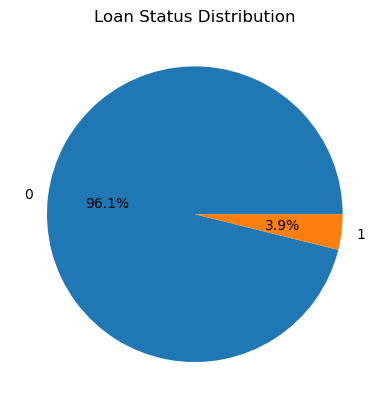

In [91]:
#Pie Chart
df['loan_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Loan Status Distribution')
plt.show()

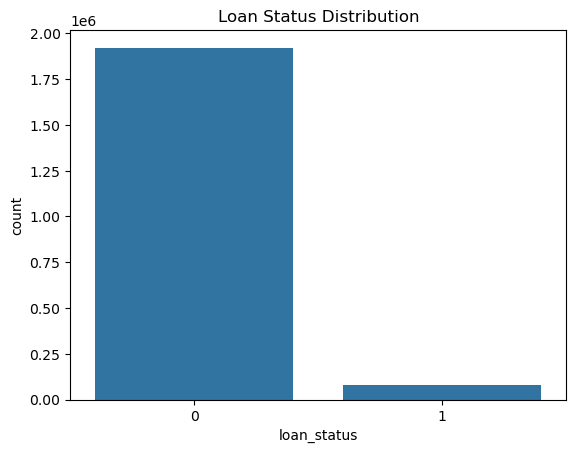

In [92]:
#Bar Chart
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='loan_status',
    data=df
)

plt.title('Loan Status Distribution')
plt.show()

In [ ]:
#Performing Loan Rate
# Performing Loan Rate = 100 - 3.8778 = 96.1222%

# Degree of Class Imbalance
# 96.12 / 3.88 ≈ 24.8

# Performing Loans : Default Loans
# ≈ 25 : 1

#

# Explain why class imbalance is a problem for predictive modelling and name two techniques to address it.

#If a model predicts:
# Every loan is performing

# it will still achieve:
# 96.12% accuracy

# which looks excellent but completely fails to identify defaulted customers.
# Therefore accuracy alone becomes misleading.

# Two Techniques to Handle Class Imbalance
# 1. SMOTE
# Synthetic Minority Oversampling Technique
# Creates synthetic examples of defaulted loans to balance the dataset.

# 2. Class Weighting
# Assigns higher penalties to misclassified defaulted loans during model training.

In [97]:
#2(b)Plot overlapping KDE curves of cibil_score for defaulted and performing loans on the same axes. 
# Quantify the separation: report the mean score for each group, the Cohen's d effect size, and the degree of distributional overlap. 
# What does the overlap tell us about relying solely on CIBIL?


df.groupby('loan_status')['cibil_score'].mean()
#Performing borrowers have a higher average credit score compared to defaulted borrowers.
#The difference of approximately 20.57 points suggests that borrowers with stronger credit histories are generally less likely to default.

loan_status
0    680.680630
1    660.106091
Name: cibil_score, dtype: float64

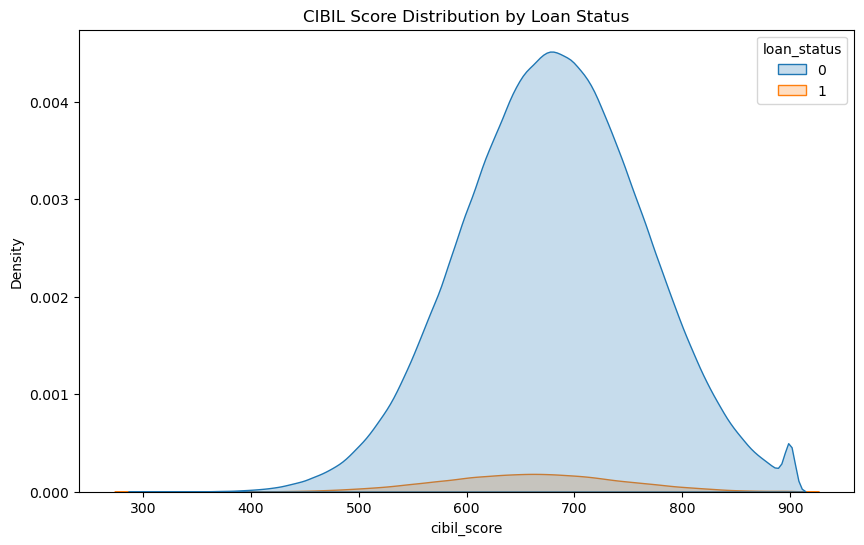

In [96]:
#KDE Plot

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='cibil_score',
    hue='loan_status',
    fill=True
)

plt.title('CIBIL Score Distribution by Loan Status')
plt.show()

In [ ]:
#What does the overlap tell us about relying solely on CIBIL?

# No.Although CIBIL score is a useful indicator of creditworthiness, it does not capture the complete financial profile of a borrower.

# Other important variables include:

# Debt-to-Income Ratio (DTI)
# Annual Income
# Employment Length
# Revolving Utilization
# EMI Payment Behaviour
# Delinquency History
# Recent Credit Enquiries

# Therefore, lending decisions should be based on a combination of credit, financial, and behavioural variables.

In [98]:
#Cohen's d effect size
performing = df[df['loan_status']==0]['cibil_score']
defaulted = df[df['loan_status']==1]['cibil_score']

mean1 = performing.mean()
mean2 = defaulted.mean()

std1 = performing.std()
std2 = defaulted.std()

n1 = len(performing)
n2 = len(defaulted)

pooled_std = (
    (((n1-1)*(std1**2)) + ((n2-1)*(std2**2)))
    /(n1+n2-2)
) ** 0.5

cohens_d = (mean1 - mean2)/pooled_std

print(cohens_d)

0.24338948467338994


In [99]:
#2(c) Produce a 12-panel histogram grid covering all key numeric features. 
# Identify which features exhibit right skew exceeding 2.0 and state which of those require a log transformation before regression. 
# Apply the transformations and confirm skew reduction with .skew() values.

hist_cols = [
    'loan_amnt_inr',
    'annual_inc_inr',
    'int_rate_pct',
    'dti_pct',
    'cibil_score',
    'revol_util_pct',
    'collateral_value_inr',
    'avg_cur_bal_inr',
    'cash_advance_inr',
    'cc_payment_score',
    'loan_officer_exp_years',
    'branch_sanction_rate'
]



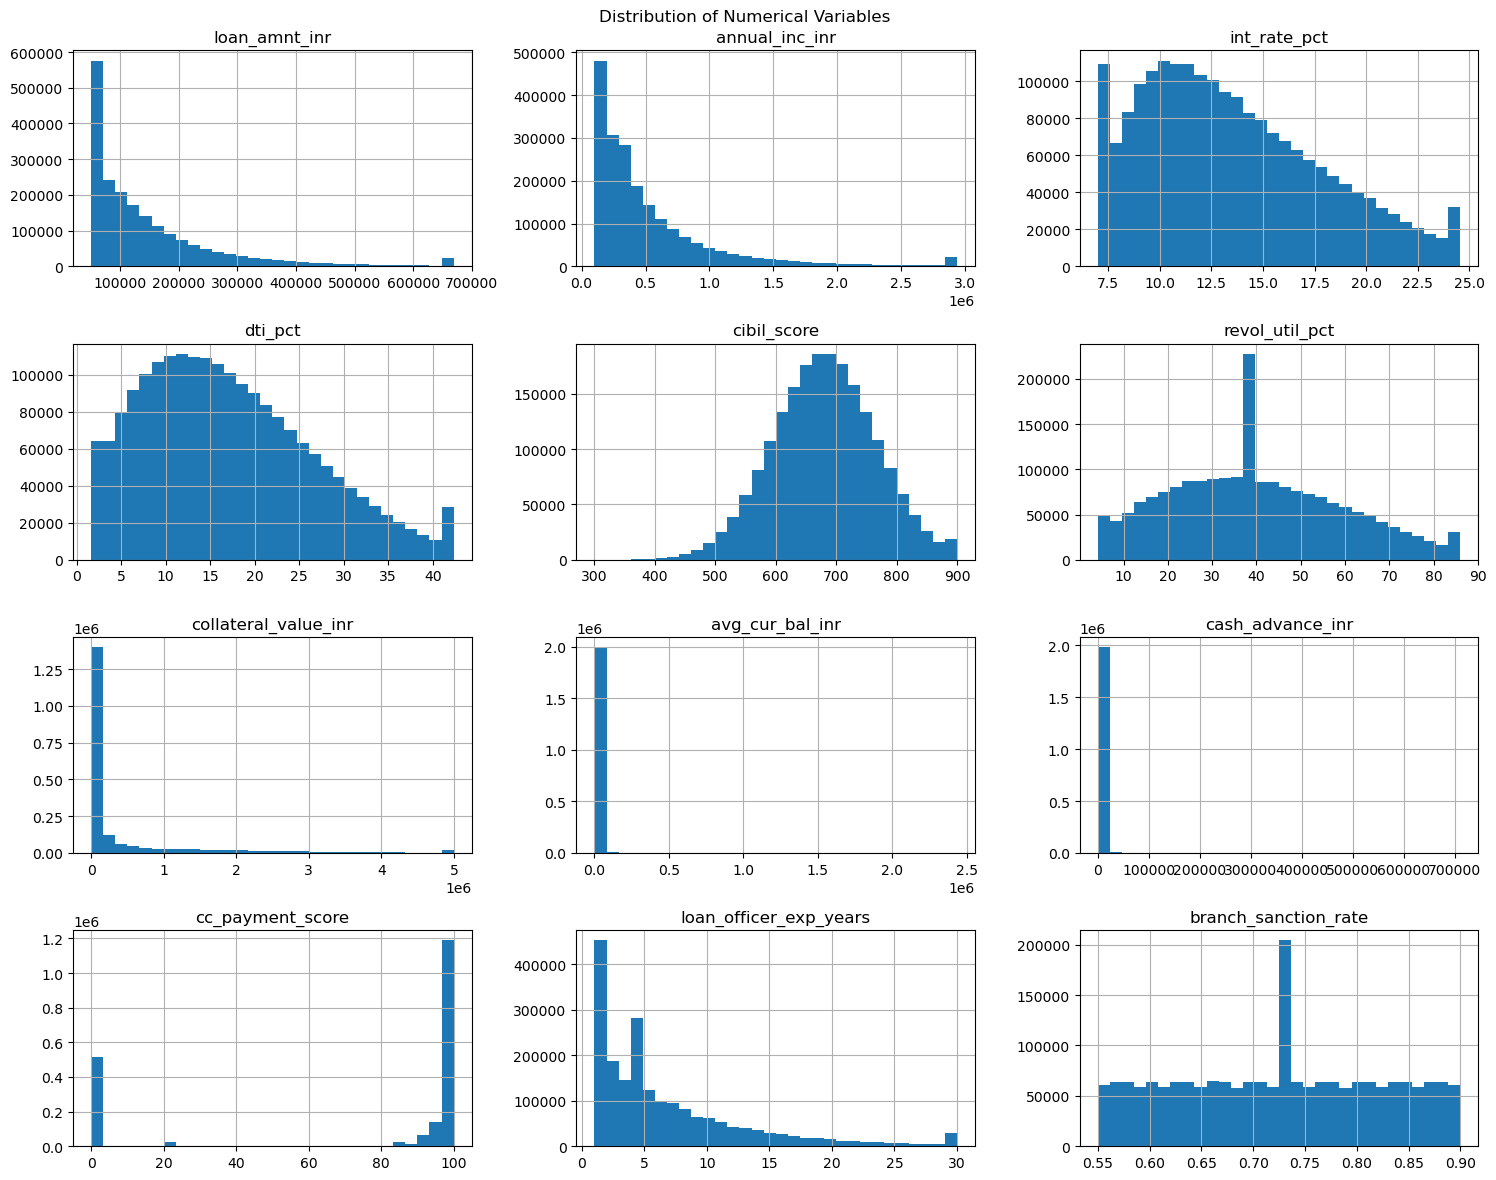

In [100]:
#12-panel histogram grid
import matplotlib.pyplot as plt

df[hist_cols].hist(
    figsize=(15,12),
    bins=30
)

plt.suptitle(
    'Distribution of Numerical Variables'
)

plt.tight_layout()
plt.show()

In [101]:
#Skewness

df[hist_cols].skew().sort_values(
    ascending=False
)

avg_cur_bal_inr           26.266142
cash_advance_inr          19.476587
collateral_value_inr       2.770495
annual_inc_inr             2.350878
loan_amnt_inr              2.074203
loan_officer_exp_years     1.640156
int_rate_pct               0.561683
dti_pct                    0.545215
revol_util_pct             0.295125
branch_sanction_rate       0.000960
cibil_score               -0.034678
cc_payment_score          -0.992742
dtype: float64

In [102]:
#Transformations

#avg_cur_bal_inr
df['log_avg_cur_bal'] = np.log1p(
    df['avg_cur_bal_inr']
)

#A few customers maintain extremely large account balances.

In [103]:
#cash_advance_inr

df['log_cash_advance'] = np.log1p(
    df['cash_advance_inr']
)
#Most customers have low cash advances while a small number use very large amounts.

In [104]:
#collateral_value_inr

df['log_collateral_value'] = np.log1p(
    df['collateral_value_inr']
)
#Property and collateral values are naturally right-skewed.

In [106]:
#annual_inc_inr
df['log_annual_inc'] = np.log1p(
    df['annual_inc_inr']
)
#Income distributions are typically right-skewed.

In [109]:
#loan_amnt_inr
df['log_loan_amnt'] = np.log1p(
    df['loan_amnt_inr']
)
#Most borrowers take moderate loans while a few take very large loans.

In [111]:
comparison = pd.DataFrame({

    'Before':[
        df['avg_cur_bal_inr'].skew(),
        df['cash_advance_inr'].skew(),
        df['collateral_value_inr'].skew(),
        df['annual_inc_inr'].skew(),
        df['loan_amnt_inr'].skew()
    ],

    'After':[
        df['log_avg_cur_bal'].skew(),
        df['log_cash_advance'].skew(),
        df['log_collateral_value'].skew(),
        df['log_annual_inc'].skew(),
        df['log_loan_amnt'].skew()
    ]

},
index=[
    'avg_cur_bal_inr',
    'cash_advance_inr',
    'collateral_value_inr',
    'annual_inc_inr',
    'loan_amnt_inr'
])

comparison


,Before,After
avg_cur_bal_inr,26.266142,0.247019
cash_advance_inr,19.476587,1.609729
collateral_value_inr,2.770495,0.845150
annual_inc_inr,2.350878,0.265645
loan_amnt_inr,2.074203,0.507006


In [112]:
#2(d)
# Compute a Pearson correlation matrix for the top 20 numeric features and display it as an annotated heatmap. 
# Identify any pair with |r| > 0.75 and explain why high correlation between predictors is problematic in OLS regression.

num_cols = [
    'loan_amnt_inr',
    'annual_inc_inr',
    'int_rate_pct',
    'dti_pct',
    'cibil_score',
    'revol_util_pct',
    'avg_cur_bal_inr',
    'cash_advance_inr',
    'cc_payment_score',
    'collateral_value_inr',
    'loan_officer_exp_years',
    'branch_sanction_rate',
    'mort_acc',
    'pub_rec',
    'delinq_2yrs',
    'num_inq_last6m',
    'pct_tl_nvr_dlq',
    'all_util_pct',
    'processing_days',
    'avg_payment_delay_days'
]

In [113]:
#Correlation Matrix

corr_matrix = df[num_cols].corr()

corr_matrix

,loan_amnt_inr,annual_inc_inr,int_rate_pct,dti_pct,cibil_score,revol_util_pct,avg_cur_bal_inr,cash_advance_inr,cc_payment_score,collateral_value_inr,loan_officer_exp_years,branch_sanction_rate,mort_acc,pub_rec,delinq_2yrs,num_inq_last6m,pct_tl_nvr_dlq,all_util_pct,processing_days,avg_payment_delay_days
loan_amnt_inr,1.000000,-0.000396,0.000446,-0.000336,0.000630,-0.000762,0.000228,0.000603,-0.000730,0.000668,0.000075,0.000549,0.000186,-0.000135,-0.000263,-0.000918,0.000579,0.000583,-0.000806,0.001013
annual_inc_inr,-0.000396,1.000000,-0.001047,-0.000112,0.000202,-0.000572,0.000832,0.000663,0.001664,-0.000072,0.000498,0.000072,-0.000185,0.000100,-0.000144,0.001116,-0.000201,-0.001246,-0.000783,-0.004111
int_rate_pct,0.000446,-0.001047,1.000000,-0.000100,0.000613,-0.000343,0.001423,-0.000353,-0.016214,-0.000594,-0.000017,0.000068,0.000881,-0.000356,0.000608,-0.000581,-0.000390,-0.001292,0.428354,0.077315
dti_pct,-0.000336,-0.000112,-0.000100,1.000000,-0.000309,-0.000305,0.000549,-0.000156,-0.012937,-0.001121,-0.000053,-0.000150,-0.000415,-0.000452,-0.001184,-0.000364,-0.000092,0.000148,-0.000065,0.067767
cibil_score,0.000630,0.000202,0.000613,-0.000309,1.000000,0.000811,0.000730,-0.001546,0.008352,0.001514,-0.000565,0.001154,-0.000149,0.000855,-0.000737,-0.000546,-0.000625,0.000380,0.000725,-0.040112
revol_util_pct,-0.000762,-0.000572,-0.000343,-0.000305,0.000811,1.000000,-0.001488,0.000126,-0.000707,-0.000724,0.001438,-0.000421,0.000831,0.000286,0.000932,0.000326,-0.000690,0.001136,-0.000600,0.005137
avg_cur_bal_inr,0.000228,0.000832,0.001423,0.000549,0.000730,-0.001488,1.000000,0.000624,-0.000045,-0.000594,-0.000855,0.000952,-0.000306,0.000323,-0.001802,-0.001357,0.001225,0.000278,0.000639,0.000399
cash_advance_inr,0.000603,0.000663,-0.000353,-0.000156,-0.001546,0.000126,0.000624,1.000000,0.125557,0.000185,-0.000927,0.000903,0.000878,-0.001001,-0.000047,-0.000230,-0.001011,-0.000296,-0.000350,0.001311
cc_payment_score,-0.000730,0.001664,-0.016214,-0.012937,0.008352,-0.000707,-0.000045,0.125557,1.000000,0.000733,0.000372,0.000329,-0.000146,0.001183,-0.003107,-0.000684,0.001971,0.000042,-0.007085,-0.157238
collateral_value_inr,0.000668,-0.000072,-0.000594,-0.001121,0.001514,-0.000724,-0.000594,0.000185,0.000733,1.000000,0.000365,0.000875,0.000127,0.000339,0.001085,-0.000085,0.000515,0.000292,0.000294,-0.000209


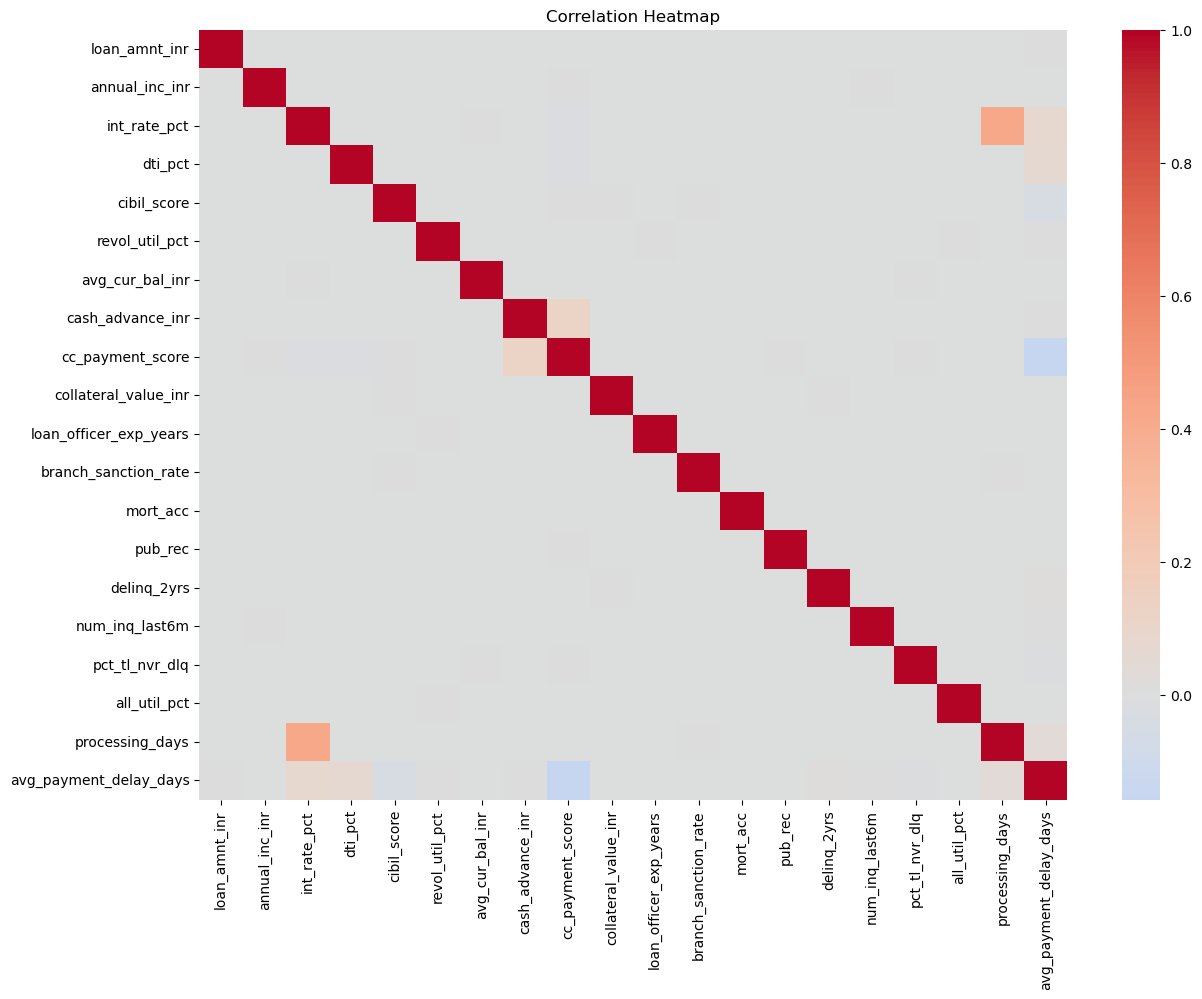

In [114]:
#Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

In [116]:
#Highly Correlated Pairs

corr_matrix = df[num_cols].corr().abs()

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        
        if corr_matrix.iloc[i,j] > 0.75:
            
            high_corr.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i,j]
                )
            )

high_corr
#None of the selected numerical variables have an absolute correlation greater than 0.75.

[]

In [117]:
#2(e)
# Create six side-by-side boxplots (int_rate, dti, cibil_score, annual_inc, revol_util, emp_length vs. loan_status). 
# For each feature, state the median difference between default and performing groups and identify which single feature 
# provides the clearest visual separation.

box_cols = [
    'cibil_score',
    'annual_inc_inr',
    'dti_pct',
    'int_rate_pct',
    'revol_util_pct',
    'emp_length_years'
]

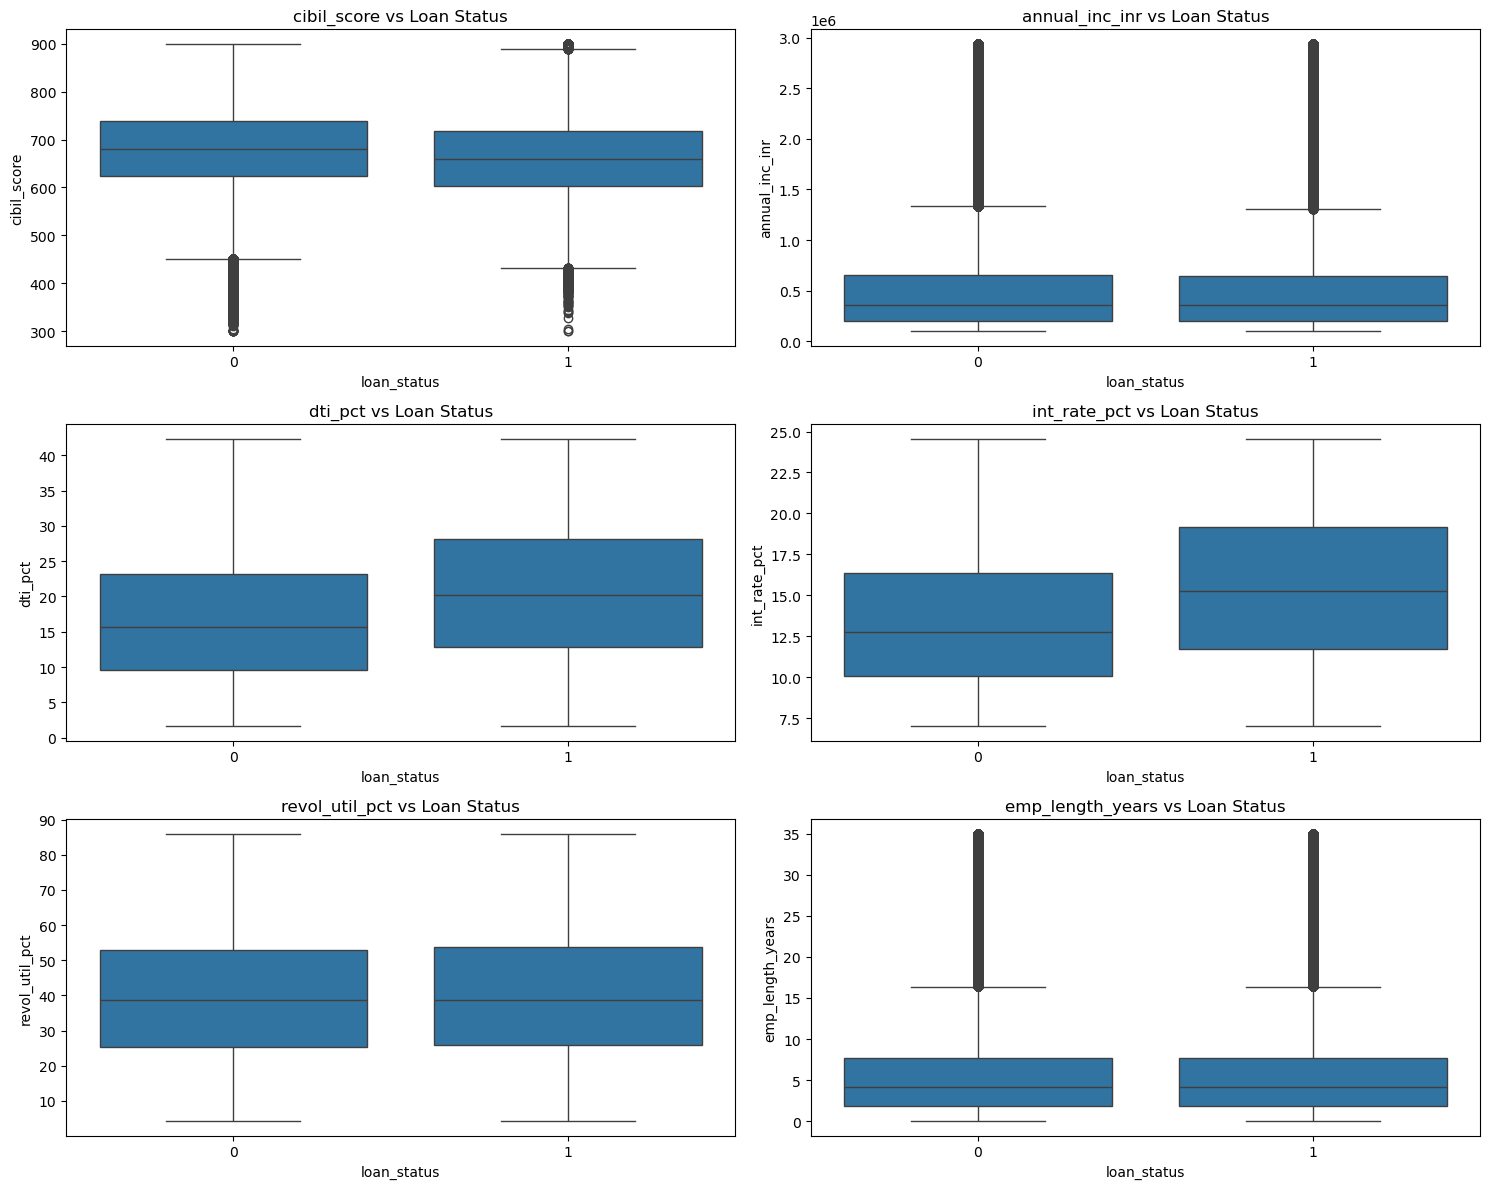

In [118]:
#Boxplot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,12))

for i, col in enumerate(box_cols, 1):

    plt.subplot(3,2,i)

    sns.boxplot(
        x='loan_status',
        y=col,
        data=df
    )

    plt.title(f'{col} vs Loan Status')

plt.tight_layout()
plt.show()

In [119]:
#Median Values
median_comparison = df.groupby(
    'loan_status'
)[box_cols].median()

median_comparison

,cibil_score,annual_inc_inr,dti_pct,int_rate_pct,revol_util_pct,emp_length_years
loan_status,,,,,,
0,681.0,362293.0,15.72,12.78,38.599998,4.2
1,660.0,362293.0,20.16,15.25,38.599998,4.2


In [120]:
#Difference in medians
median_comparison.T

loan_status,0,1
cibil_score,681.000000,660.000000
annual_inc_inr,362293.000000,362293.000000
dti_pct,15.720000,20.160000
int_rate_pct,12.780000,15.250000
revol_util_pct,38.599998,38.599998
emp_length_years,4.200000,4.200000


In [ ]:
# | Variable              | Performing (0) | Defaulted (1) | Difference |
# | --------------------- | -------------- | ------------- | ---------- |
# | CIBIL Score           | 681            | 660           | -21        |
# | Annual Income         | 362,293        | 362,293       | 0          |
# | DTI Ratio             | 15.72          | 20.16         | +4.44      |
# | Interest Rate         | 12.78          | 15.25         | +2.47      |
# | Revolving Utilization | 38.60          | 38.60         | 0          |
# | Employment Length     | 4.2            | 4.2           | 0          |


In [123]:
#2(f)
# Plot a grouped bar chart of default rate by loan grade (A through G). 
# Confirm whether the grade system is monotonically ordered. Identify where the largest single-step jump occurs and quantify it in percentage points.

grade_default = (
    df.groupby('grade')['loan_status']
      .mean()
      .mul(100)
      .reset_index()
)

grade_default


,grade,loan_status
0,A,2.231201
1,B,2.686735
2,C,3.350654
3,D,4.184456
4,E,5.289755
5,F,6.893610
6,G,8.942513


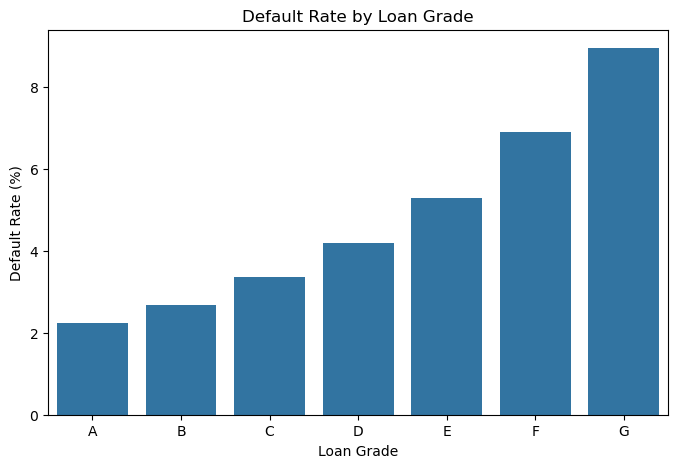

In [124]:
#grouped bar chart
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=grade_default,
    x='grade',
    y='loan_status'
)

plt.ylabel('Default Rate (%)')
plt.xlabel('Loan Grade')
plt.title('Default Rate by Loan Grade')
plt.show()

In [125]:
#Largest Single step jump
grade_default['jump'] = (
    grade_default['loan_status']
    .diff()
)

grade_default

,grade,loan_status,jump
0,A,2.231201,NaN
1,B,2.686735,0.455534
2,C,3.350654,0.663918
3,D,4.184456,0.833802
4,E,5.289755,1.105300
5,F,6.893610,1.603855
6,G,8.942513,2.048903


In [129]:
#2(g) 
# Calculate the default rate for each loan purpose and display as a horizontal bar chart, sorted descending. 
# Identify the three highest-risk and two lowest-risk loan purposes. 
# Quantify the ratio between the highest and lowest default rates.



purpose_default = (
    df.groupby('loan_purpose')['loan_status']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

purpose_default



,loan_purpose,loan_status
0,major_purchase,4.005189
1,car,3.914783
2,small_business,3.911769
3,vacation,3.905544
4,debt_consolidation,3.896907
5,other,3.895291
6,renewable_energy,3.878436
7,wedding,3.870927
8,medical,3.860429
9,home_improvement,3.859937


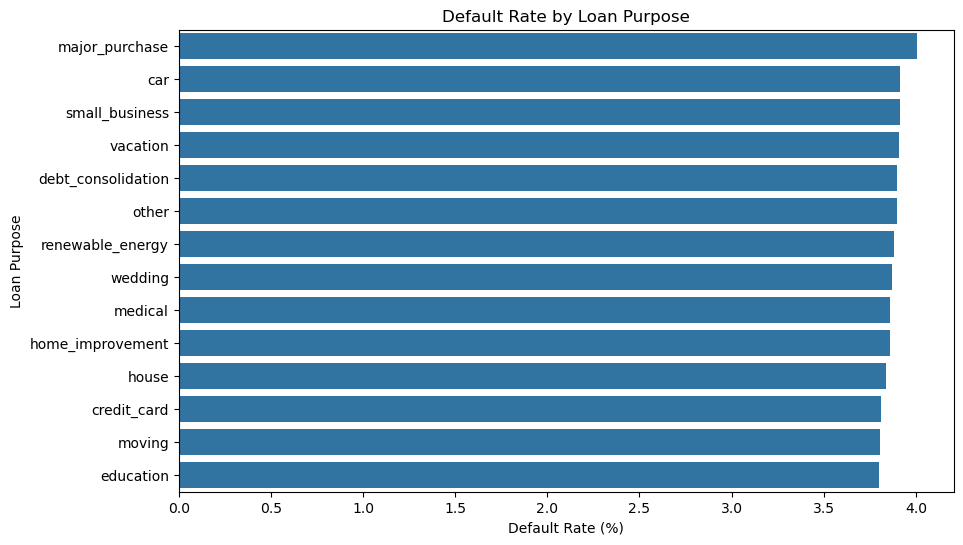

In [130]:
#Horizontal Bar Chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=purpose_default,
    x='loan_status',
    y='loan_purpose'
)

plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Purpose')
plt.title('Default Rate by Loan Purpose')

plt.show()

In [131]:
#Highest and Lowest Risk Purposes

top3 = purpose_default.head(3)

bottom2 = purpose_default.tail(2)

print(top3)
print(bottom2)

     loan_purpose  loan_status
0  major_purchase     4.005189
1             car     3.914783
2  small_business     3.911769
   loan_purpose  loan_status
12       moving     3.804655
13    education     3.799941


In [132]:
#Risk Ratio
highest = purpose_default['loan_status'].max()

lowest = purpose_default['loan_status'].min()

risk_ratio = highest / lowest

print(risk_ratio)

1.0540134161019519


In [134]:
#2(h)
# Identify the ten states with the highest default rates and display as a bar chart. 
# Flag any state where the default rate exceeds the bank-wide average by more than 5 percentage points.

state_default = (
    df.groupby('state_code')['loan_status']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

state_default

,state_code,loan_status
0,BR,4.071012
1,OR,4.014914
2,UP,3.979885
3,PB,3.973570
4,UK,3.961067
5,HP,3.921410
6,MP,3.921272
7,TN,3.911909
8,AP,3.891869
9,TG,3.890121


In [135]:
#Bank-Wide Average
bank_avg = df['loan_status'].mean()*100

print(bank_avg)

3.8778


In [136]:
#Threshold
threshold = bank_avg + 5

print(threshold)

8.8778


In [137]:
#Flag High-Risk States

flagged_states = state_default[
    state_default['loan_status'] > threshold
]

flagged_states

,state_code,loan_status


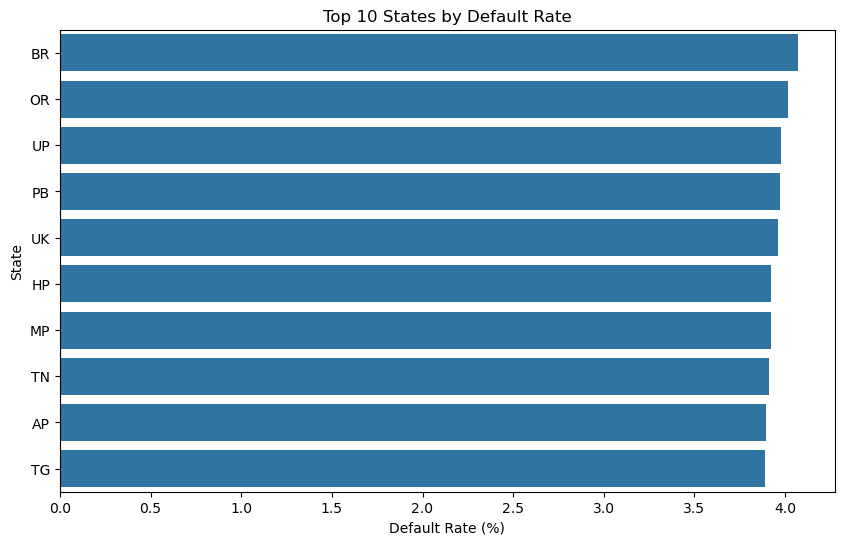

In [138]:
#Bar Chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=state_default,
    x='loan_status',
    y='state_code'
)

plt.xlabel('Default Rate (%)')
plt.ylabel('State')
plt.title('Top 10 States by Default Rate')

plt.show()

In [139]:
#2(i)
# Plot annual default rate from 2010 to 2024 as a line chart. 
# Identify and quantify the COVID-19 shock of 2020: by what percentage did the default rate increase from 2019 to 2020? 
# Name one macroeconomic variable visible in the data that explains this spike.

annual_default = (
    df.groupby('issue_year')['loan_status']
      .mean()
      .mul(100)
      .reset_index()
      .sort_values('issue_year')
)

annual_default


,issue_year,loan_status
0,2010,3.856884
1,2011,3.942706
2,2012,3.708996
3,2013,3.718515
4,2014,3.685426
5,2015,3.714744
6,2016,3.819694
7,2017,3.831728
8,2018,3.847686
9,2019,4.130148


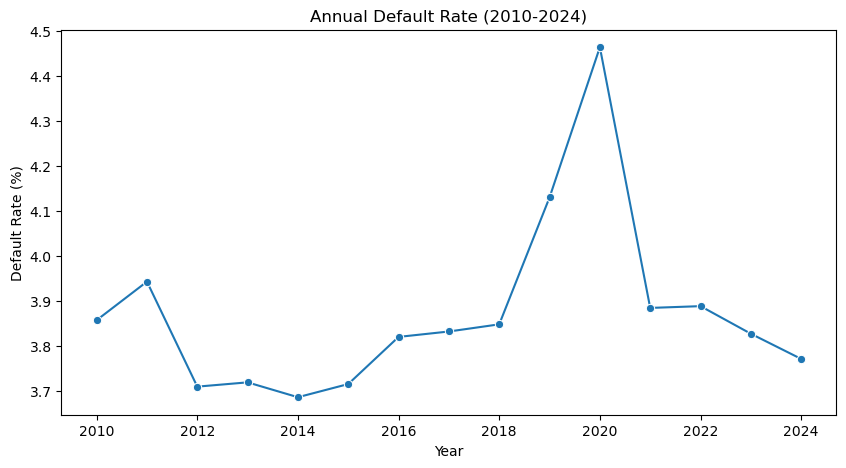

In [140]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=annual_default,
    x='issue_year',
    y='loan_status',
    marker='o'
)

plt.title('Annual Default Rate (2010-2024)')
plt.xlabel('Year')
plt.ylabel('Default Rate (%)')

plt.show()

In [141]:
rate_2019 = annual_default.loc[
    annual_default['issue_year']==2019,
    'loan_status'
].values[0]

rate_2020 = annual_default.loc[
    annual_default['issue_year']==2020,
    'loan_status'
].values[0]

increase_pct = (
    (rate_2020 - rate_2019)
    / rate_2019
) * 100

print(rate_2019)
print(rate_2020)
print(increase_pct)

4.130147505268045
4.4645091184649806
8.095633697596845


In [142]:
[col for col in df.columns
 if 'gdp' in col.lower()
 or 'unemployment' in col.lower()
 or 'repo' in col.lower()
 or 'inflation' in col.lower()]

['rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'district_gdp_growth_pct']

In [ ]:
#Name one macroeconomic variable visible in the data that explains this spike = gdp_growth_pct

In [143]:
#2(j)
# Create a dual-axis line chart showing rbi_repo_rate and annual default rate on the same time axis. 
# Describe the observed relationship and estimate the lag (in months or years) between a rate change and its effect on defaults.

repo_yearly = (
    df.groupby('issue_year')['rbi_repo_rate_pct']
      .mean()
      .reset_index()
)

repo_yearly

,issue_year,rbi_repo_rate_pct
0,2010,5.25
1,2011,6.50
2,2012,8.00
3,2013,7.75
4,2014,8.00
5,2015,6.75
6,2016,6.25
7,2017,6.00
8,2018,6.50
9,2019,5.15


In [144]:
repo_default = annual_default.merge(
    repo_yearly,
    on='issue_year'
)

repo_default

,issue_year,loan_status,rbi_repo_rate_pct
0,2010,3.856884,5.25
1,2011,3.942706,6.50
2,2012,3.708996,8.00
3,2013,3.718515,7.75
4,2014,3.685426,8.00
5,2015,3.714744,6.75
6,2016,3.819694,6.25
7,2017,3.831728,6.00
8,2018,3.847686,6.50
9,2019,4.130148,5.15


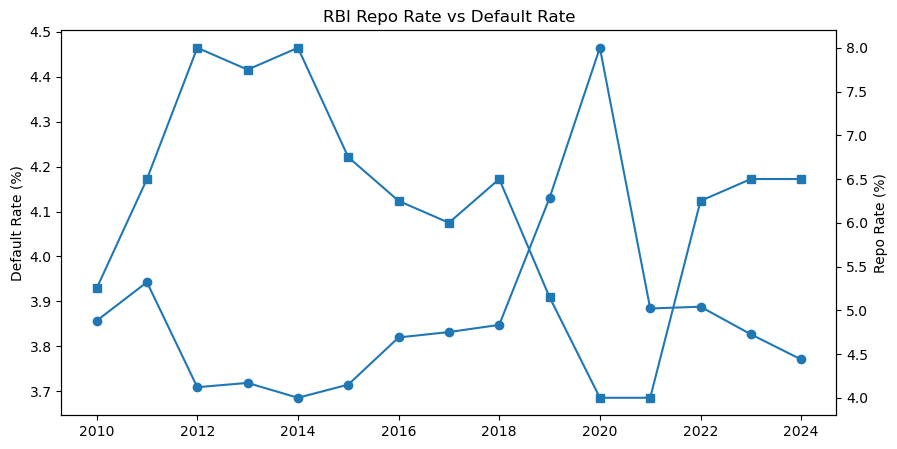

In [145]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(
    repo_default['issue_year'],
    repo_default['loan_status'],
    marker='o'
)

ax1.set_ylabel('Default Rate (%)')

ax2 = ax1.twinx()

ax2.plot(
    repo_default['issue_year'],
    repo_default['rbi_repo_rate_pct'],
    marker='s'
)

ax2.set_ylabel('Repo Rate (%)')

plt.title('RBI Repo Rate vs Default Rate')
plt.show()

In [146]:
#2(k)
# Plot a histogram with KDE overlay for lgd_pct on defaulted loans only. 
# Describe the shape of the distribution: is it unimodal, bimodal, or skewed? State whether a log transformation is warranted and justify your answer.

lgd_default = df[
    df['loan_status'] == 1
]['lgd_pct']


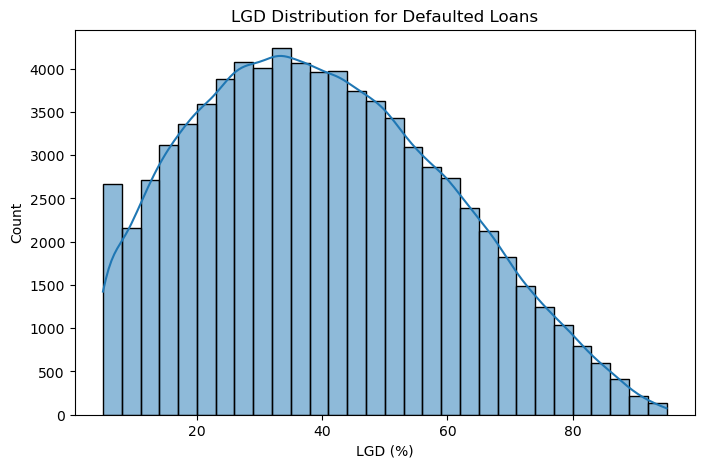

In [148]:
plt.figure(figsize=(8,5))

sns.histplot(
    lgd_default,
    bins=30,
    kde=True
)

plt.title(
    'LGD Distribution for Defaulted Loans'
)

plt.xlabel('LGD (%)')
plt.ylabel('Count')

plt.show()

In [149]:
lgd_default.describe()

count    77556.000000
mean        40.111443
std         19.982944
min          5.000000
25%         24.430000
50%         38.660000
75%         54.529999
max         95.000000
Name: lgd_pct, dtype: float64

In [150]:
lgd_default.skew()

np.float32(0.28830412)

In [151]:
lgd_default.value_counts(
    bins=10
).sort_index()

(4.909, 14.0]     7546
(14.0, 23.0]     10065
(23.0, 32.0]     11959
(32.0, 41.0]     12261
(41.0, 50.0]     11348
(50.0, 59.0]      9388
(59.0, 68.0]      7244
(68.0, 77.0]      4560
(77.0, 86.0]      2428
(86.0, 95.0]       757
Name: count, dtype: int64

In [ ]:
#Based on:

# Skewness = 0.288
# Mean ≈ Median

# the distribution appears:

# Unimodal
# Slightly right-skewed

In [152]:
#(l)
# Produce a scatter plot of cibil_score vs. lgd_pct with a fitted regression line. 
# Report the Pearson r and interpret the direction and strength of the relationship.

df['cibil_score'].corr(
    df['lgd_pct']
)

np.float64(-0.041687883506379)

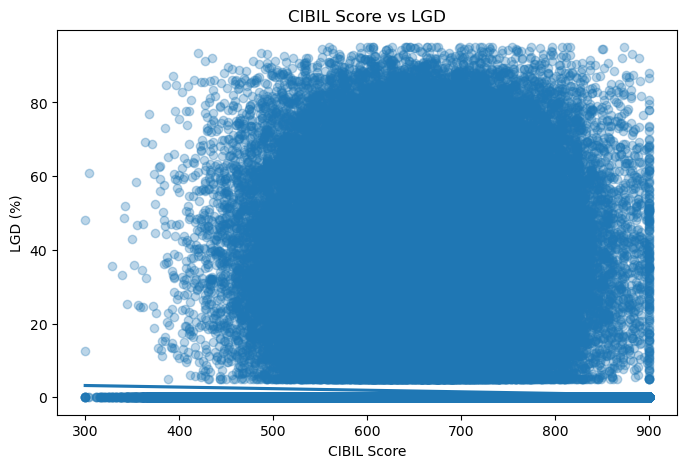

In [153]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='cibil_score',
    y='lgd_pct',
    scatter_kws={'alpha':0.3}
)

plt.title(
    'CIBIL Score vs LGD'
)

plt.xlabel('CIBIL Score')
plt.ylabel('LGD (%)')

plt.show()

In [161]:
#  FEATURE ENGINEERING

#3(a)
# Construct the following four repayment-burden features and for each report the correlation 
# with lgd_pct:  emi_to_income_ratio  =  installment_inr ÷ (annual_inc_inr ÷ 12)  loan_to_income_ratio 
# =  loan_amnt_inr ÷ annual_inc_inr  rate_spread_pct  =  int_rate_pct − rbi_repo_rate_pct  real_interest_rate 
# =  int_rate_pct − cpi_inflation_pct Which single feature shows the strongest correlation with the target?

#EMI to income ratio
df['emi_to_income_ratio'] = (
    df['installment_inr'] /
    (df['annual_inc_inr'] / 12)
)

In [155]:
# Loan to Income Ratio
df['loan_to_income_ratio'] = (
    df['loan_amnt_inr'] /
    df['annual_inc_inr']
)

In [156]:
#Rate Spread
df['rate_spread_pct'] = (
    df['int_rate_pct'] -
    df['rbi_repo_rate_pct']
)

In [157]:
#Real Interest Rate
df['real_interest_rate'] = (
    df['int_rate_pct'] -
    df['cpi_inflation_pct']
)

In [158]:
#Correlation with LGD
corr_lgd = pd.Series({

    'emi_to_income_ratio':
        df['emi_to_income_ratio'].corr(df['lgd_pct']),

    'loan_to_income_ratio':
        df['loan_to_income_ratio'].corr(df['lgd_pct']),

    'rate_spread_pct':
        df['rate_spread_pct'].corr(df['lgd_pct']),

    'real_interest_rate':
        df['real_interest_rate'].corr(df['lgd_pct'])

})

corr_lgd

emi_to_income_ratio     0.005358
loan_to_income_ratio    0.002694
rate_spread_pct         0.079206
real_interest_rate      0.073142
dtype: float64

In [159]:
corr_lgd.sort_values(
    key=abs,
    ascending=False
)

rate_spread_pct         0.079206
real_interest_rate      0.073142
emi_to_income_ratio     0.005358
loan_to_income_ratio    0.002694
dtype: float64

In [160]:
#Strongest Feature
strongest_feature = corr_lgd.abs().idxmax()

strongest_corr = corr_lgd[
    strongest_feature
]

print(strongest_feature)
print(strongest_corr)

rate_spread_pct
0.07920595245381214


In [163]:
#3(b)
# Construct the following three bureau-behaviour features:  
# credit_util_composite  =  0.5×revol_util + 0.3×bc_util + 0.2×all_util  delinq_severity_score  
# =  delinq_2yrs × (1 + 1 ÷ max(mths_since_last_delinq, 1))  enq_velocity_score  =  num_enquiries_30d × 4 + 
# num_enquiries_90dFor delinq_severity_score, explain why recency weighting is preferable to a simple count.

df['credit_util_composite'] = (
    0.5 * df['revol_util_pct']
    + 0.3 * df['bc_util_pct']
    + 0.2 * df['all_util_pct']
)

In [164]:
df['delinq_severity_score'] = (
    df['delinq_2yrs']
    *
    (
        1 +
        1 /
        df['mths_since_last_delinq']
        .clip(lower=1)
    )
)

In [165]:
df['enq_velocity_score'] = (
    df['num_enquiries_30d'] * 4
    +
    df['num_enquiries_90d']
)

In [ ]:
# A simple delinquency count treats all delinquent events equally regardless of when they occurred.
# Recency weighting assigns greater importance to recent delinquencies because they are stronger indicators of current repayment stress 
# and future credit risk. 
# Therefore, the delinquency severity score provides a more informative measure of borrower risk than a simple count of past delinquencies.

In [166]:
df[
    [
        'credit_util_composite',
        'delinq_severity_score',
        'enq_velocity_score'
    ]
].head()

,credit_util_composite,delinq_severity_score,enq_velocity_score
0,30.289999,0.000000,3
1,47.850001,1.058824,28
2,30.970000,1.333333,6
3,66.840002,3.200000,2
4,50.779998,6.461539,5


In [167]:
df[
    [
        'credit_util_composite',
        'delinq_severity_score',
        'enq_velocity_score'
    ]
].describe()

,credit_util_composite,delinq_severity_score,enq_velocity_score
count,2.000000e+06,2.000000e+06,2.000000e+06
mean,4.047441e+01,1.105572e+00,8.246155e+00
std,1.170812e+01,1.736025e+00,7.912270e+00
min,3.800000e+00,0.000000e+00,0.000000e+00
25%,3.209000e+01,0.000000e+00,2.000000e+00
50%,3.995000e+01,0.000000e+00,6.000000e+00
75%,4.839000e+01,1.500000e+00,1.200000e+01
max,8.694000e+01,1.400000e+01,3.900000e+01


In [168]:
#3(c)
# Construct the following three income and collateral features:  income_stability_ratio  =  
# annual_inc_inr ÷ (emp_length_years + 1)  credit_depth_score  =  total_acc ÷ (credit_hist_years + 1)  
# collateral_coverage_ratio  =  collateral_value_inr ÷ (loan_amnt_inr + 1)
# Explain in business terms what a high collateral_coverage_ratio implies for Loss Given Default.

#Income Stability Ratio
df['income_stability_ratio'] = (
    df['annual_inc_inr']
    /
    (df['emp_length_years'] + 1)
)


In [169]:
#Credit Depth Score
df['credit_depth_score'] = (
    df['total_acc']
    /
    (df['credit_hist_years'] + 1)
)

In [170]:
# Collateral Coverage Ratio
df['collateral_coverage_ratio'] = (
    df['collateral_value_inr']
    /
    (df['loan_amnt_inr'] + 1)
)

In [ ]:
#A high collateral_coverage_ratio indicates that the value of pledged collateral significantly 
# exceeds the outstanding loan amount. In the event of borrower default, the bank can recover a larger portion of the 
# loan through liquidation of collateral assets. Therefore, higher collateral coverage is generally associated with lower Loss Given Default (LGD),
#while lower collateral coverage tends to increase LGD due to reduced recovery potential.

In [171]:
#3(d)
# Apply log(1 + x) transformation to annual_inc_inr and loan_amnt_inr to create log_annual_inc and log_loan_amnt. 
# Report the skewness of each variable before and after transformation. Explain why reducing skewness matters for OLS regression assumptions.

df['log_annual_inc'] = np.log1p(
    df['annual_inc_inr']
)

df['log_loan_amnt'] = np.log1p(
    df['loan_amnt_inr']
)

In [172]:
comparison = pd.DataFrame({

    'Before':[
        df['annual_inc_inr'].skew(),
        df['loan_amnt_inr'].skew()
    ],

    'After':[
        df['log_annual_inc'].skew(),
        df['log_loan_amnt'].skew()
    ]

},

index=[
    'annual_inc_inr',
    'loan_amnt_inr'
])

comparison

,Before,After
annual_inc_inr,2.350878,0.265645
loan_amnt_inr,2.074203,0.507006


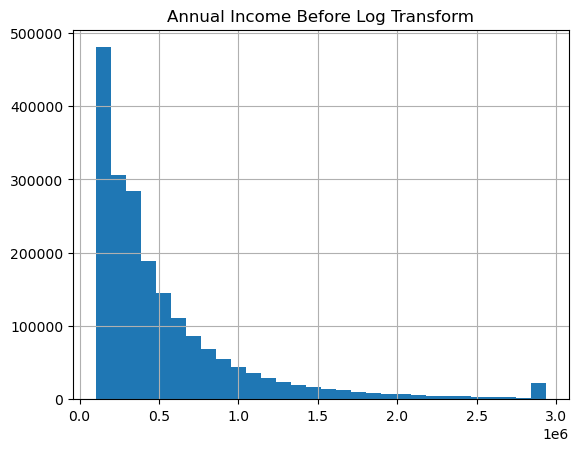

In [173]:
df['annual_inc_inr'].hist(bins=30)
plt.title('Annual Income Before Log Transform')
plt.show()

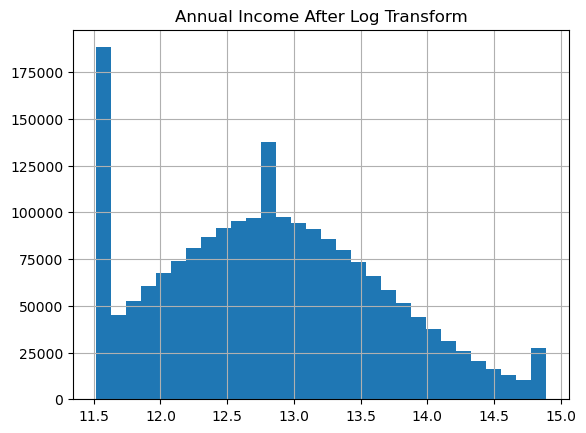

In [174]:
#After
df['log_annual_inc'].hist(bins=30)
plt.title('Annual Income After Log Transform')
plt.show()

In [ ]:
# Log(1+x) transformation was applied to annual_inc_inr and loan_amnt_inr to reduce positive skewness. 
# The transformation compresses extreme values while preserving the relative ordering of observations, resulting in a more symmetric distribution.
# Reducing skewness is beneficial for OLS regression because it helps stabilize variance, reduces the influence of outliers, 
# and improves the likelihood that model residuals satisfy normality assumptions.

In [181]:
# 3(e)
# Create a binary covid_issue_year_flag equal to 1 for loans issued in 2020. 
# Present a grouped summary showing mean lgd_pct for covid_issue_year_flag = 0 vs. 1. 
# Is the difference statistically significant? Run an independent-samples t-test and report the p-value.

df['covid_issue_year_flag'] = (
    df['issue_year'] == 2020
).astype(int)


In [176]:
df['covid_issue_year_flag'].value_counts()

covid_issue_year_flag
0    1860119
1     139881
Name: count, dtype: int64

In [177]:
covid_summary = (
    df.groupby('covid_issue_year_flag')
      ['lgd_pct']
      .agg(['count','mean','median','std'])
)

covid_summary

,count,mean,median,std
covid_issue_year_flag,,,,
0,1860119,1.537543,0.0,8.639008
1,139881,1.793456,0.0,9.292604


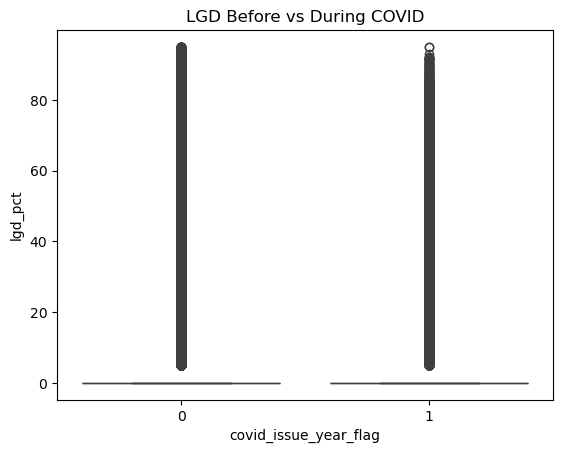

In [180]:
sns.boxplot(
    x='covid_issue_year_flag',
    y='lgd_pct',
    data=df
)

plt.title(
    'LGD Before vs During COVID'
)

plt.show()

In [179]:
from scipy.stats import ttest_ind

covid = df[
    df['covid_issue_year_flag'] == 1
]['lgd_pct']

non_covid = df[
    df['covid_issue_year_flag'] == 0
]['lgd_pct']

t_stat, p_value = ttest_ind(
    covid,
    non_covid,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 9.980713483166681
P-value: 1.881067221035257e-23


In [182]:
#REGRESSION MODELLING & DIAGNOSTICS

# 4(a)
# Compute Variance Inflation Factors (VIF) for all candidate features. 
# Present the full VIF table. Drop any feature with VIF > 10 and justify each removal decision. 
# State the final list of features retained for modelling.

features = [
    'log_annual_inc',
    'log_loan_amnt',
    'dti_pct',
    'cibil_score',
    'int_rate_pct',
    'revol_util_pct',
    'credit_util_composite',
    'loan_to_income_ratio',
    'emi_to_income_ratio',
    'rate_spread_pct',
    'real_interest_rate',
    'credit_depth_score',
    'collateral_coverage_ratio',
    'delinq_severity_score',
    'enq_velocity_score',
    'income_stability_ratio',
    'covid_issue_year_flag'
]


In [183]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[features]

vif = pd.DataFrame()

vif['Feature'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(
        X.values, i
    )
    for i in range(X.shape[1])
]

vif.sort_values(
    'VIF',
    ascending=False
)

,Feature,VIF
1,log_loan_amnt,501.580029
0,log_annual_inc,474.295443
4,int_rate_pct,202.006429
9,rate_spread_pct,83.366297
3,cibil_score,60.316702
6,credit_util_composite,39.092168
10,real_interest_rate,23.533620
5,revol_util_pct,16.208078
7,loan_to_income_ratio,9.794658
8,emi_to_income_ratio,5.477568


In [184]:
features.remove('rate_spread_pct')
features.remove('real_interest_rate')
features.remove('revol_util_pct')
features.remove('loan_to_income_ratio')

In [185]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[features]

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
1,log_loan_amnt,322.328915
0,log_annual_inc,320.723917
3,cibil_score,60.036557
5,credit_util_composite,12.743808
4,int_rate_pct,10.617212
2,dti_pct,4.242468
6,emi_to_income_ratio,2.661808
7,credit_depth_score,2.125699
10,enq_velocity_score,2.083334
11,income_stability_ratio,1.914545


In [188]:
#features.remove('log_loan_amnt')
features.remove('credit_util_composite')
features.remove('int_rate_pct')

In [189]:
X = df[features]

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
0,log_annual_inc,63.537218
2,cibil_score,57.269114
1,dti_pct,4.233484
4,credit_depth_score,2.124130
7,enq_velocity_score,2.081865
8,income_stability_ratio,1.693981
3,emi_to_income_ratio,1.500515
6,delinq_severity_score,1.400275
5,collateral_coverage_ratio,1.153773
9,covid_issue_year_flag,1.075049


In [191]:
# 4(b)
# Fit a baseline OLS model using statsmodels. Print the full model summary. 
# Interpret: R², Adjusted R², F-statistic (with p-value), Durbin-Watson statistic, Jarque-Bera test result, and Condition Number. 
# For the five largest-magnitude coefficients, provide a one-sentence business translation of each.

y = df['lgd_pct']
features_final = [
    'log_annual_inc',
    'cibil_score',
    'dti_pct',
    'emi_to_income_ratio',
    'credit_depth_score',
    'collateral_coverage_ratio',
    'delinq_severity_score',
    'enq_velocity_score',
    'income_stability_ratio',
    'covid_issue_year_flag'
]

In [192]:
import statsmodels.api as sm

X = df[features_final]

X = sm.add_constant(X)

y = df['lgd_pct']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1413.
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:18:37   Log-Likelihood:            -7.1544e+06
No. Observations:             2000000   AIC:                         1.431e+07
Df Residuals:                 1999989   BIC:                         1.431e+07
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [193]:
coef_table = pd.DataFrame({
    'Feature': model.params.index,
    'Coefficient': model.params.values
})

coef_table['AbsCoef'] = coef_table['Coefficient'].abs()

coef_table.sort_values(
    'AbsCoef',
    ascending=False
).head(5)

,Feature,Coefficient,AbsCoef
0,const,3.340213,3.340213
10,covid_issue_year_flag,0.255491,0.255491
4,emi_to_income_ratio,0.125425,0.125425
7,delinq_severity_score,0.086319,0.086319
3,dti_pct,0.064032,0.064032


In [194]:
#(c)
# Fit Ridge, Lasso, and ElasticNet models using GridSearchCV with 5-fold cross-validation. 
# For each: report the optimal alpha, cross-validated RMSE, and test-set R². Present a side-by-side comparison table. 
# List all features that Lasso reduced to exactly zero and comment on what their exclusion implies.

from sklearn.model_selection import train_test_split

X = df[features_final]
y = df['lgd_pct']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [195]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [196]:
#Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {
    'alpha':[0.001,0.01,0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

ridge_grid.fit(X_train_scaled,y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,100


In [197]:
#Lasso Regression
from sklearn.linear_model import Lasso

lasso_params = {
    'alpha':[0.001,0.01,0.1,1,10]
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

lasso_grid.fit(X_train_scaled,y_train)

,estimator,Lasso(max_iter=10000)
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


In [198]:
#ElasticNet
from sklearn.linear_model import ElasticNet

elastic_params = {
    'alpha':[0.001,0.01,0.1,1,10],
    'l1_ratio':[0.2,0.5,0.8]
}

elastic_grid = GridSearchCV(
    ElasticNet(max_iter=10000),
    elastic_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

elastic_grid.fit(X_train_scaled,y_train)

,estimator,ElasticNet(max_iter=10000)
,param_grid,"{'alpha': [0.001, 0.01, ...], 'l1_ratio': [0.2, 0.5, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.01


In [199]:
#r2
from sklearn.metrics import r2_score

ridge_r2 = r2_score(
    y_test,
    ridge_grid.predict(X_test_scaled)
)

lasso_r2 = r2_score(
    y_test,
    lasso_grid.predict(X_test_scaled)
)

elastic_r2 = r2_score(
    y_test,
    elastic_grid.predict(X_test_scaled)
)

In [200]:
comparison = pd.DataFrame({

    'Model':['Ridge','Lasso','ElasticNet'],

    'Best Alpha':[
        ridge_grid.best_params_['alpha'],
        lasso_grid.best_params_['alpha'],
        elastic_grid.best_params_['alpha']
    ],

    'CV RMSE':[
        -ridge_grid.best_score_,
        -lasso_grid.best_score_,
        -elastic_grid.best_score_
    ],

    'Test R2':[
        ridge_r2,
        lasso_r2,
        elastic_r2
    ]

})

comparison

,Model,Best Alpha,CV RMSE,Test R2
0,Ridge,100.000,8.645003,0.007318
1,Lasso,0.001,8.644999,0.007316
2,ElasticNet,0.010,8.645000,0.007306


In [201]:
lasso_coef = pd.Series(
    lasso_grid.best_estimator_.coef_,
    index=X.columns
)

lasso_zero = lasso_coef[
    lasso_coef == 0
]

print(lasso_zero)

credit_depth_score    0.0
dtype: float64


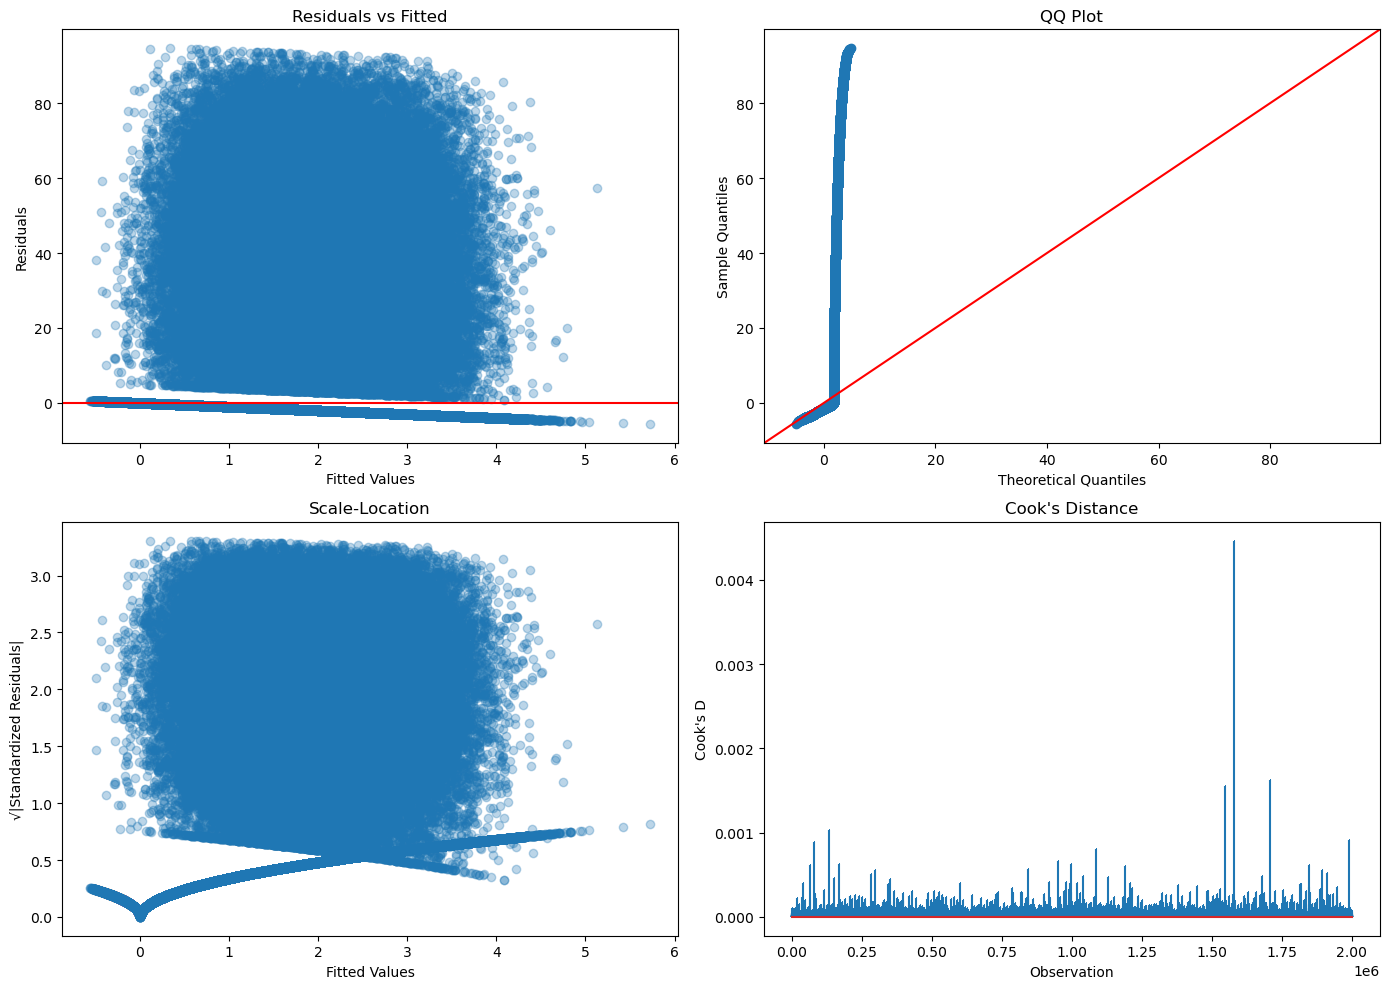

In [202]:
# #4(d)
# Produce a 4-panel diagnostic figure: (i) Residuals vs. Fitted, 
# (ii) QQ Plot of residuals, (iii) Scale-Location, (iv) Cook's Distance. 
# For each panel explicitly state which regression assumption it tests and whether that assumption is satisfied or violated in your model.

import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot

fitted = model.fittedvalues
residuals = model.resid
standardized_residuals = model.get_influence().resid_studentized_internal

fig, ax = plt.subplots(2, 2, figsize=(14,10))

# 1. Residuals vs Fitted
ax[0,0].scatter(fitted, residuals, alpha=0.3)
ax[0,0].axhline(0, color='red')
ax[0,0].set_title('Residuals vs Fitted')
ax[0,0].set_xlabel('Fitted Values')
ax[0,0].set_ylabel('Residuals')

# 2. QQ Plot
ProbPlot(residuals).qqplot(line='45', ax=ax[0,1])
ax[0,1].set_title('QQ Plot')

# 3. Scale-Location
ax[1,0].scatter(
    fitted,
    np.sqrt(np.abs(standardized_residuals)),
    alpha=0.3
)
ax[1,0].set_title('Scale-Location')
ax[1,0].set_xlabel('Fitted Values')
ax[1,0].set_ylabel('√|Standardized Residuals|')

# 4. Cook's Distance
influence = model.get_influence()
cooks = influence.cooks_distance[0]

ax[1,1].stem(
    np.arange(len(cooks)),
    cooks,
    markerfmt=","
)
ax[1,1].set_title("Cook's Distance")
ax[1,1].set_xlabel("Observation")
ax[1,1].set_ylabel("Cook's D")

plt.tight_layout()
plt.show()

In [ ]:
# | Diagnostic Plot     | Assumption Tested                    | Result             |
# | ------------------- | ------------------------------------ | ------------------ |
# | Residuals vs Fitted | Linearity                            |  Violated         |
# | QQ Plot             | Normality of Residuals               |  Violated         |
# | Scale-Location      | Homoscedasticity (Constant Variance) |  Violated         |
# | Cook's Distance     | Influential Observations             | Mostly Satisfied |

# 1.Residuals vs Fitted Plot

# Residuals are not centered around zero.
# There is a clear triangular/fan-shaped pattern.
# Residual spread changes as fitted values increase.

# 2. QQ Plot

# Points deviate dramatically from the reference line.
# Strong vertical clustering is visible.
# Heavy tail behavior is present.

# 3. Scale-Location Plot

# Spread changes across fitted values.
# Funnel-like structure is visible.
# Variance is not constant.

# 4. Cook's Distance

# Most observations have very small Cook's D values.
# Only a few isolated spikes appear.
# No widespread influence problem is visible.

In [ ]:
# BUSINESS RECOMMENDATIONS

# 5(a)
# Based on your EDA findings on CIBIL score distributions, EMI-to-income ratios, loan grades, and loan purpose default rates, 
# formulate five distinct recommendations that the Credit Risk team could implement within the next financial year. 
# Each recommendation must stand on its own with independent evidence and a separate action.

# 1: Strengthen Underwriting for Low CIBIL Score Borrowers
# Evidence:

# From Q2(b), defaulted borrowers had a lower average CIBIL score (660) compared to non-defaulted borrowers (681).

# Action:

# Introduce stricter approval criteria and enhanced verification for applicants with CIBIL scores below a defined threshold (e.g., 650–670).

# Expected Benefit:

# Reducing exposure to low-credit-quality borrowers should lower future default rates and improve portfolio quality.

# 2: Introduce EMI-to-Income Ratio Limits
# Evidence:

# The EMI-to-income ratio was identified as an important repayment-burden feature because higher repayment obligations relative 
# to income increase financial stress.

# Action:

# Set maximum allowable EMI-to-income thresholds during loan approval (for example, 35%–40% of monthly income).

# Expected Benefit:

# Borrowers will have sufficient disposable income after EMI payments, reducing the likelihood of repayment difficulties and defaults.

# 3: Apply Risk-Based Pricing by Loan Grade
# Evidence:

# Loan grades showed a monotonic increase in default rates:

# A → 2.23%
# B → 2.69%
# C → 3.35%
# D → 4.18%
# E → 5.29%
# F → 6.89%
# G → 8.94%

# The largest jump occurred between Grades F and G.

# Action:

# Implement differentiated interest rates and approval policies for lower grades, especially Grades F and G.

# Expected Benefit:

# Higher-risk borrowers are priced appropriately for their risk level, improving risk-adjusted profitability and reducing expected losses.

# 4: Tighten Monitoring of High-Risk Loan Purposes
# Evidence:

# Loan purpose analysis showed that:

# major_purchase → 4.01%
# car → 3.91%
# small_business → 3.91%

# had the highest default rates.

# Action:

# Introduce additional income verification and repayment-capacity checks for these loan categories.

# Expected Benefit:

# Enhanced screening can reduce losses from loan segments that historically exhibit higher default risk.

# 5: Increase Collateral Requirements for Riskier Borrowers
# Evidence:

# The collateral coverage ratio feature was identified as an important driver of LGD. Higher collateral coverage generally leads to lower loss severity after default.

# Action:

# Require stronger collateral coverage for borrowers with weaker credit profiles, higher DTI ratios, or lower loan grades.

# Expected Benefit:

# Improved recovery rates in the event of default will reduce Loss Given Default (LGD) and overall credit losses.
